# Pipeline NLP Open Source pour l’Analyse des Alertes Réglementaires RASFF

Ce notebook présente un pipeline NLP open source complet dédié à l’analyse automatique des alertes réglementaires du système RASFF (Rapid Alert System for Food and Feed). L’objectif principal est de remplacer l’utilisation d’un LLM propriétaire dans le module `llm_regulatory_analyzer.py` par une solution open source, reproductible et adaptée aux textes multilingues.

Le pipeline couvre quatre fonctionnalités principales :

- Classification du niveau de risque : **CRITIQUE**, **ATTENTION**, **INFO**
- Extraction d’entités : pays, produits, dates, dangers et contaminants
- Résumé automatique des alertes en français
- Génération d’un brief exécutif destiné aux PME marocaines

Le modèle principal utilisé pour la classification est **`xlm-roberta-base`**, choisi pour ses performances robustes sur les tâches NLP multilingues et sa capacité à traiter efficacement des données réglementaires internationales.

In [6]:
!pip install -q transformers datasets accelerate evaluate pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 71.4 MB/s eta 0:00:00:00:0100:01


In [7]:
import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

import pycountry

warnings.filterwarnings("ignore")

In [8]:
class CFG:
    DATA_DIR = "/kaggle/input/datasets/badrrhachi0/fine-tuning-nlp"  # À modifier selon ton dataset Kaggle
    
    TRAIN_FILE = "nlp_dataset_combined.csv"
    ENRICHED_FILE = "rasff_nlp_dataset.csv"
    MAROC_FILE = "rasff_maroc_dataset.csv"
    
    MODEL_NAME = "xlm-roberta-base"
    OUTPUT_DIR = "/kaggle/working/xlm_roberta_rasff_classifier"
    
    MAX_LENGTH = 160
    BATCH_SIZE = 8
    EPOCHS = 4
    LEARNING_RATE = 2e-5
    WEIGHT_DECAY = 0.01
    SEED = 42
    
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device utilisé :", device)

Device utilisé : cuda


In [9]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)

In [10]:
train_path = os.path.join(CFG.DATA_DIR, CFG.TRAIN_FILE)
enriched_path = os.path.join(CFG.DATA_DIR, CFG.ENRICHED_FILE)
maroc_path = os.path.join(CFG.DATA_DIR, CFG.MAROC_FILE)

df_train = pd.read_csv(train_path)
df_enriched = pd.read_csv(enriched_path)
df_maroc = pd.read_csv(maroc_path)

print("Dataset entraînement :", df_train.shape)
print("Dataset enrichi :", df_enriched.shape)
print("Dataset Maroc :", df_maroc.shape)

display(df_train.head())
display(df_enriched.head())
display(df_maroc.head())

Dataset entraînement : (17065, 3)
Dataset enrichi : (29829, 9)
Dataset Maroc : (16583, 10)


,texte,niveau,source
0,Salmonella spp. in sesame seeds from Nigeria |...,CRITIQUE,RASFF
1,Ciprodinilo en Mango de Colombia // Ciprodinil...,CRITIQUE,RASFF
2,Undeclared consignements of frozen strawberrie...,ATTENTION,RASFF
3,Detection of Listeria monocytogenes in pre-sli...,CRITIQUE,RASFF
4,Detection of Listeria monocytogenes in smoked ...,CRITIQUE,RASFF


,texte,niveau,category,classification,risk_decision,origin,year,month,maroc_relevant
0,Salmonella spp. in sesame seeds from Nigeria |...,CRITIQUE,"nuts, nut products and seeds",border rejection notification,serious,Nigeria,2026,5,1
1,Salmonella in soya bean meal from Argentina | ...,ATTENTION,feed materials,information notification for follow-up,potentially serious,Argentina,2026,5,0
2,Ciprodinilo en Mango de Colombia // Ciprodinil...,CRITIQUE,fruits and vegetables,border rejection notification,serious,Colombia,2026,5,1
3,Consignment frozen fried bean curd skipped vet...,INFO,other food product / mixed,information notification for follow-up,not serious,South Korea,2026,5,0
4,Undeclared consignements of frozen strawberrie...,ATTENTION,fruits and vegetables,information notification for follow-up,potential risk,Egypt,2026,5,1


,texte,niveau,category,classification,risk_decision,origin,year,month,maroc_relevant,source
0,Salmonella spp. in sesame seeds from Nigeria |...,CRITIQUE,"nuts, nut products and seeds",border rejection notification,serious,Nigeria,2026,5,1,RASFF
1,Ciprodinilo en Mango de Colombia // Ciprodinil...,CRITIQUE,fruits and vegetables,border rejection notification,serious,Colombia,2026,5,1,RASFF
2,Undeclared consignements of frozen strawberrie...,ATTENTION,fruits and vegetables,information notification for follow-up,potential risk,Egypt,2026,5,1,RASFF
3,Detection of Listeria monocytogenes in pre-sli...,CRITIQUE,fish and fish products,alert notification,serious,France,2026,5,1,RASFF
4,Detection of Listeria monocytogenes in smoked ...,CRITIQUE,fish and fish products,alert notification,serious,Belgium,2026,5,1,RASFF


In [11]:
print("Colonnes df_train :", df_train.columns.tolist())
print("Colonnes df_enriched :", df_enriched.columns.tolist())
print("Colonnes df_maroc :", df_maroc.columns.tolist())

Colonnes df_train : ['texte', 'niveau', 'source']
Colonnes df_enriched : ['texte', 'niveau', 'category', 'classification', 'risk_decision', 'origin', 'year', 'month', 'maroc_relevant']
Colonnes df_maroc : ['texte', 'niveau', 'category', 'classification', 'risk_decision', 'origin', 'year', 'month', 'maroc_relevant', 'source']


In [12]:
def clean_text(text):
    """
    Nettoie un texte brut :
    - remplace les valeurs manquantes
    - supprime les retours à la ligne
    - supprime les espaces multiples
    - retire les espaces au début et à la fin
    """
    if pd.isna(text):
        return ""
    
    text = str(text)
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    
    return text


# Utiliser le dataset enrichi comme base principale
df = df_enriched.copy()

# Nettoyage des colonnes principales
df = df.dropna(subset=["texte", "niveau"])
df["texte"] = df["texte"].apply(clean_text)
df["niveau"] = df["niveau"].astype(str).str.strip().str.upper()

# Garder uniquement les labels valides
valid_labels = ["CRITIQUE", "ATTENTION", "INFO"]
df = df[df["niveau"].isin(valid_labels)]

# Nettoyage des colonnes textuelles supplémentaires
for col in ["category", "classification", "risk_decision", "origin"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).apply(clean_text)

# Conversion des colonnes numériques
for col in ["year", "month", "maroc_relevant"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Suppression des doublons
df = df.drop_duplicates(subset=["texte"]).reset_index(drop=True)

print("Dataset après nettoyage :", df.shape)
display(df.head())

Dataset après nettoyage : (26705, 9)


,texte,niveau,category,classification,risk_decision,origin,year,month,maroc_relevant
0,Salmonella spp. in sesame seeds from Nigeria |...,CRITIQUE,"nuts, nut products and seeds",border rejection notification,serious,Nigeria,2026,5,1
1,Salmonella in soya bean meal from Argentina | ...,ATTENTION,feed materials,information notification for follow-up,potentially serious,Argentina,2026,5,0
2,Ciprodinilo en Mango de Colombia // Ciprodinil...,CRITIQUE,fruits and vegetables,border rejection notification,serious,Colombia,2026,5,1
3,Consignment frozen fried bean curd skipped vet...,INFO,other food product / mixed,information notification for follow-up,not serious,South Korea,2026,5,0
4,Undeclared consignements of frozen strawberrie...,ATTENTION,fruits and vegetables,information notification for follow-up,potential risk,Egypt,2026,5,1


niveau
CRITIQUE     18627
INFO          4354
ATTENTION     3724
Name: count, dtype: int64


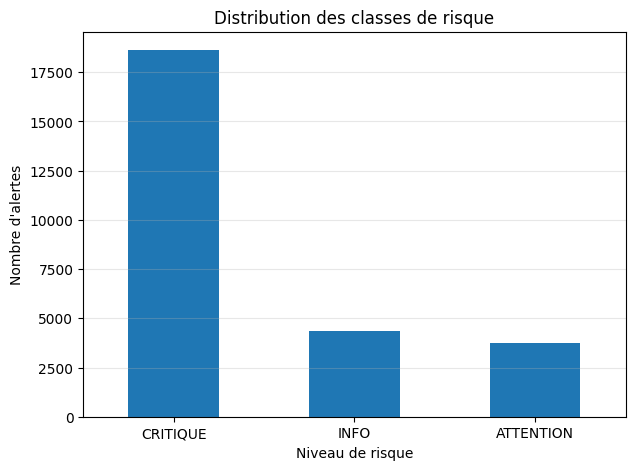

In [13]:
class_counts = df["niveau"].value_counts()
print(class_counts)

plt.figure(figsize=(7, 5))
class_counts.plot(kind="bar")
plt.title("Distribution des classes de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre d'alertes")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

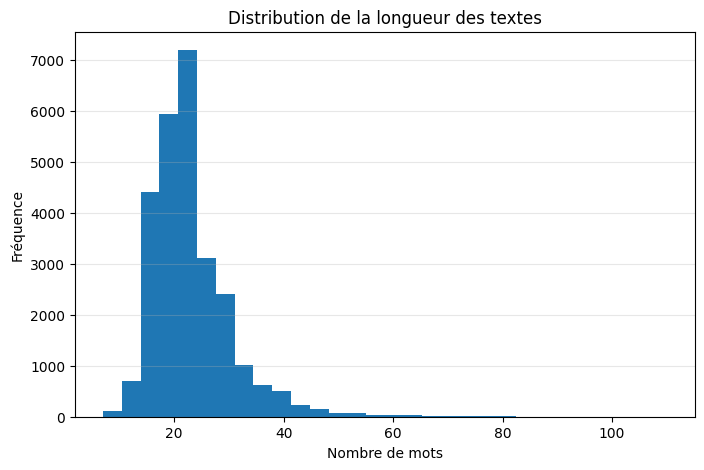

count    26705.000000
mean        23.062722
std          7.517395
min          7.000000
25%         18.000000
50%         22.000000
75%         26.000000
max        110.000000
Name: text_length, dtype: float64


In [14]:
df["text_length"] = df["texte"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
plt.hist(df["text_length"], bins=30)
plt.title("Distribution de la longueur des textes")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.grid(axis="y", alpha=0.3)
plt.show()

print(df["text_length"].describe())

In [15]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["niveau"])

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

print("label2id :", label2id)
print("id2label :", id2label)

label2id : {'ATTENTION': 0, 'CRITIQUE': 1, 'INFO': 2}
id2label : {0: 'ATTENTION', 1: 'CRITIQUE', 2: 'INFO'}


In [16]:
train_df, temp_df = train_test_split(
    df,
    test_size=CFG.TEST_SIZE + CFG.VAL_SIZE,
    stratify=df["label"],
    random_state=CFG.SEED
)

relative_val_size = CFG.VAL_SIZE / (CFG.TEST_SIZE + CFG.VAL_SIZE)

val_df, test_df = train_test_split(
    temp_df,
    test_size=1 - relative_val_size,
    stratify=temp_df["label"],
    random_state=CFG.SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train :", train_df.shape)
print("Validation :", val_df.shape)
print("Test :", test_df.shape)

Train : (18693, 11)
Validation : (4006, 11)
Test : (4006, 11)


,train,validation,test
niveau,,,
CRITIQUE,13038,2795,2794
INFO,3048,653,653
ATTENTION,2607,558,559


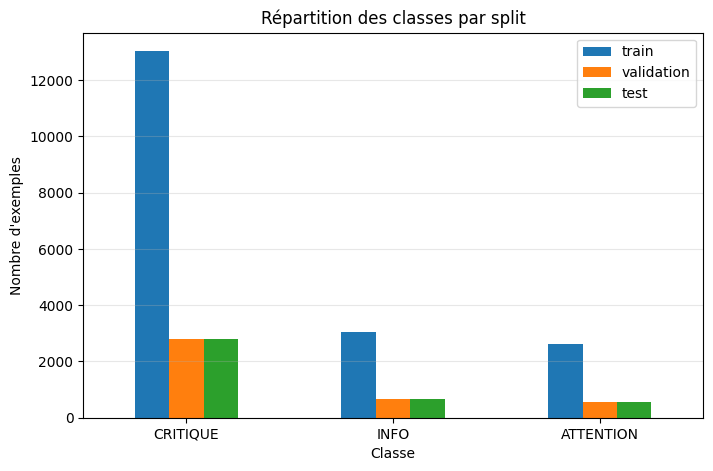

In [17]:
split_counts = pd.DataFrame({
    "train": train_df["niveau"].value_counts(),
    "validation": val_df["niveau"].value_counts(),
    "test": test_df["niveau"].value_counts()
}).fillna(0)

display(split_counts)

split_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Répartition des classes par split")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Tokenizer XLM-RoBERTa

In [18]:
tokenizer = AutoTokenizer.from_pretrained(CFG.MODEL_NAME)

sample_text = train_df.loc[0, "texte"]
tokens = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=CFG.MAX_LENGTH
)

print(sample_text)
print(tokens.keys())

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Salmonella Typhimurium in turkey meat from France via Belgium | poultry meat and poultry meat products | Salmonella typhimurium DT 7 - {pathogenic micro-organisms} | Netherlands
KeysView({'input_ids': [0, 6565, 3796, 4523, 33417, 10706, 1162, 316, 23, 2130, 19770, 163, 257, 1295, 9942, 1829, 199458, 6, 58745, 160, 202, 15123, 163, 257, 136, 160, 202, 15123, 163, 257, 38742, 6, 58745, 6565, 3796, 4523, 11417, 10706, 1162, 316, 6, 41072, 361, 20, 10666, 128405, 62976, 1771, 11948, 9, 43425, 8780, 7, 8152, 6, 58745, 231118, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [20]:
class RASFFDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        
        return item

train_dataset = RASFFDataset(train_df["texte"], train_df["label"], tokenizer, CFG.MAX_LENGTH)
val_dataset = RASFFDataset(val_df["texte"], val_df["label"], tokenizer, CFG.MAX_LENGTH)
test_dataset = RASFFDataset(test_df["texte"], test_df["label"], tokenizer, CFG.MAX_LENGTH)

In [21]:
num_labels = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    CFG.MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model.to(device)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [22]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )
    
    return {
        "accuracy": accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1
    }

In [23]:
training_args = TrainingArguments(
    output_dir=CFG.OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=CFG.LEARNING_RATE,
    per_device_train_batch_size=CFG.BATCH_SIZE,
    per_device_eval_batch_size=CFG.BATCH_SIZE,
    num_train_epochs=CFG.EPOCHS,
    weight_decay=CFG.WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
    seed=CFG.SEED
)

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ]
)

In [25]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,1.475306,1.320971,0.753120,0.709485,0.753120,0.719347
2,1.262984,1.214968,0.770344,0.743106,0.770344,0.749066
3,1.133699,1.249233,0.782327,0.755678,0.782327,0.754087
4,1.040005,1.234705,0.784573,0.761480,0.784573,0.766828


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [26]:
val_metrics = trainer.evaluate(val_dataset)
print(json.dumps(val_metrics, indent=4))

{
    "eval_loss": 1.2347053289413452,
    "eval_accuracy": 0.7845731402895657,
    "eval_precision_weighted": 0.7614799826537808,
    "eval_recall_weighted": 0.7845731402895657,
    "eval_f1_weighted": 0.766827635909496,
    "eval_runtime": 42.0373,
    "eval_samples_per_second": 95.296,
    "eval_steps_per_second": 5.971,
    "epoch": 4.0
}


In [27]:
test_predictions = trainer.predict(test_dataset)

test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids
test_preds = np.argmax(test_logits, axis=1)

test_report = classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

   ATTENTION       0.54      0.30      0.39       559
    CRITIQUE       0.84      0.93      0.88      2794
        INFO       0.58      0.52      0.55       653

    accuracy                           0.78      4006
   macro avg       0.65      0.58      0.61      4006
weighted avg       0.75      0.78      0.76      4006



,precision,recall,f1-score,support
ATTENTION,0.539683,0.304114,0.389016,559.000000
CRITIQUE,0.836235,0.928418,0.879919,2794.000000
INFO,0.578947,0.522205,0.549114,653.000000
accuracy,0.775087,0.775087,0.775087,0.775087
macro avg,0.651622,0.584913,0.606016,4006.000000
weighted avg,0.752914,0.775087,0.757495,4006.000000


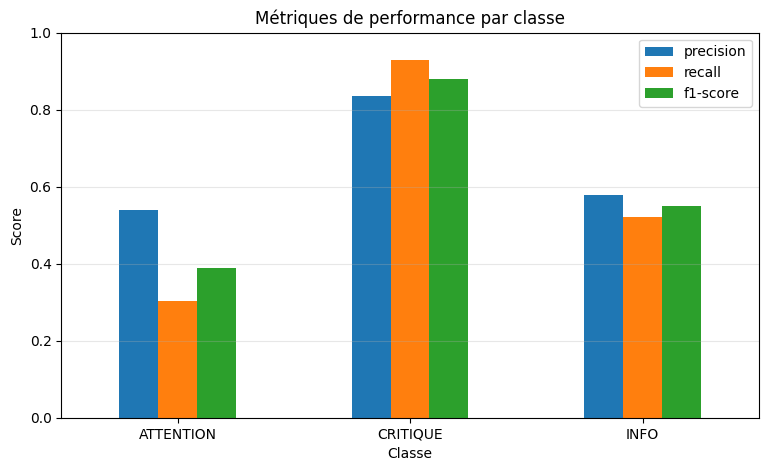

In [28]:
metrics_df = pd.DataFrame(test_report).transpose()
display(metrics_df)

metrics_df.iloc[:-3][["precision", "recall", "f1-score"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Métriques de performance par classe")
plt.xlabel("Classe")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

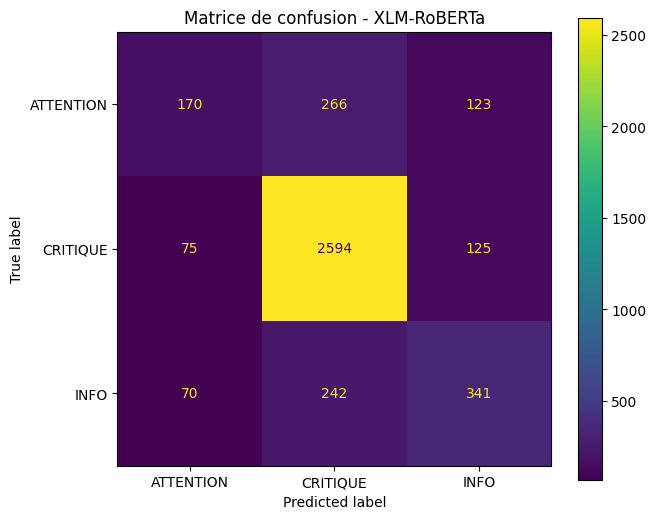

In [29]:
cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Matrice de confusion - XLM-RoBERTa")
plt.show()

# Benchmark 1 — Analyse des résultats

Le premier benchmark utilise uniquement la colonne `texte` comme entrée du modèle XLM-RoBERTa.

Les résultats obtenus montrent que le modèle atteint une performance globale correcte, avec une accuracy d’environ 78 % et un F1-score pondéré d’environ 76 %.

Cependant, l’analyse détaillée montre que le modèle détecte très bien la classe `CRITIQUE`, mais rencontre des difficultés avec les classes `ATTENTION` et `INFO`.

Cette limite peut être expliquée par deux facteurs principaux :

1. Le déséquilibre du dataset, car la classe `CRITIQUE` est majoritaire.
2. La proximité sémantique entre les classes `ATTENTION`, `INFO` et `CRITIQUE`.

Pour améliorer les performances, un deuxième benchmark est proposé en enrichissant l’entrée du modèle avec des informations supplémentaires disponibles dans le dataset : catégorie du produit, type de notification, décision de risque et pays d’origine.

In [30]:
# Sauvegarde Benchmark 1


benchmark_1_results = {
    "benchmark": "Benchmark 1 - XLM-RoBERTa avec texte seul",
    "input_features": ["texte"],
    "accuracy": accuracy_score(test_labels, test_preds),
    "precision_weighted": precision_recall_fscore_support(
        test_labels, test_preds, average="weighted", zero_division=0
    )[0],
    "recall_weighted": precision_recall_fscore_support(
        test_labels, test_preds, average="weighted", zero_division=0
    )[1],
    "f1_weighted": precision_recall_fscore_support(
        test_labels, test_preds, average="weighted", zero_division=0
    )[2],
    "f1_macro": precision_recall_fscore_support(
        test_labels, test_preds, average="macro", zero_division=0
    )[2]
}

benchmark_1_results

{'benchmark': 'Benchmark 1 - XLM-RoBERTa avec texte seul',
 'input_features': ['texte'],
 'accuracy': 0.7750873689465801,
 'precision_weighted': 0.7529143503678343,
 'recall_weighted': 0.7750873689465801,
 'f1_weighted': 0.7574947953474737,
 'f1_macro': 0.6060163129678254}

In [31]:
# Rapport détaillé Benchmark 1

benchmark_1_report_df = pd.DataFrame(test_report).transpose()

display(benchmark_1_report_df)

benchmark_1_report_path = "/kaggle/working/benchmark_1_classification_report.csv"
benchmark_1_report_df.to_csv(benchmark_1_report_path, index=True)

print("Rapport Benchmark 1 sauvegardé :", benchmark_1_report_path)

,precision,recall,f1-score,support
ATTENTION,0.539683,0.304114,0.389016,559.000000
CRITIQUE,0.836235,0.928418,0.879919,2794.000000
INFO,0.578947,0.522205,0.549114,653.000000
accuracy,0.775087,0.775087,0.775087,0.775087
macro avg,0.651622,0.584913,0.606016,4006.000000
weighted avg,0.752914,0.775087,0.757495,4006.000000


Rapport Benchmark 1 sauvegardé : /kaggle/working/benchmark_1_classification_report.csv


# Benchmark 2 — XLM-RoBERTa avec entrée enrichie

Dans ce deuxième benchmark, l’objectif est d’améliorer la classification en ajoutant des informations métier disponibles dans le dataset enrichi.

Au lieu d’utiliser uniquement la colonne `texte`, nous construisons une nouvelle entrée textuelle appelée `model_input`, qui combine :

- le texte original de l’alerte ;
- la catégorie du produit ;
- le type de notification RASFF ;
- la décision de risque ;
- le pays d’origine.

Cette approche permet au modèle de recevoir plus de contexte métier pour mieux distinguer les niveaux `CRITIQUE`, `ATTENTION` et `INFO`.

In [32]:
# Construction de model_input

def build_model_input(row):
    return (
        f"Texte alerte : {row.get('texte', '')}. "
        f"Catégorie produit : {row.get('category', '')}. "
        f"Type notification : {row.get('classification', '')}. "
        f"Décision risque : {row.get('risk_decision', '')}. "
        f"Pays origine : {row.get('origin', '')}."
    )

df["model_input"] = df.apply(build_model_input, axis=1)

display(df[["texte", "model_input", "niveau"]].head())

,texte,model_input,niveau
0,Salmonella spp. in sesame seeds from Nigeria |...,Texte alerte : Salmonella spp. in sesame seeds...,CRITIQUE
1,Salmonella in soya bean meal from Argentina | ...,Texte alerte : Salmonella in soya bean meal fr...,ATTENTION
2,Ciprodinilo en Mango de Colombia // Ciprodinil...,Texte alerte : Ciprodinilo en Mango de Colombi...,CRITIQUE
3,Consignment frozen fried bean curd skipped vet...,Texte alerte : Consignment frozen fried bean c...,INFO
4,Undeclared consignements of frozen strawberrie...,Texte alerte : Undeclared consignements of fro...,ATTENTION


In [33]:
# Exemple d'entrée enrichie


print("Texte original :")
print(df.loc[0, "texte"])

print("\nEntrée enrichie envoyée au modèle :")
print(df.loc[0, "model_input"])

print("\nLabel réel :")
print(df.loc[0, "niveau"])

Texte original :
Salmonella spp. in sesame seeds from Nigeria | nuts, nut products and seeds | Salmonella - {pathogenic micro-organisms} | Nigeria

Entrée enrichie envoyée au modèle :
Texte alerte : Salmonella spp. in sesame seeds from Nigeria | nuts, nut products and seeds | Salmonella - {pathogenic micro-organisms} | Nigeria. Catégorie produit : nuts, nut products and seeds. Type notification : border rejection notification. Décision risque : serious. Pays origine : Nigeria.

Label réel :
CRITIQUE


In [35]:
# Split Benchmark 2

train_df_b2, temp_df_b2 = train_test_split(
    df,
    test_size=CFG.TEST_SIZE + CFG.VAL_SIZE,
    stratify=df["label"],
    random_state=CFG.SEED
)

relative_val_size = CFG.VAL_SIZE / (CFG.TEST_SIZE + CFG.VAL_SIZE)

val_df_b2, test_df_b2 = train_test_split(
    temp_df_b2,
    test_size=1 - relative_val_size,
    stratify=temp_df_b2["label"],
    random_state=CFG.SEED
)

train_df_b2 = train_df_b2.reset_index(drop=True)
val_df_b2 = val_df_b2.reset_index(drop=True)
test_df_b2 = test_df_b2.reset_index(drop=True)

print("Train Benchmark 2 :", train_df_b2.shape)
print("Validation Benchmark 2 :", val_df_b2.shape)
print("Test Benchmark 2 :", test_df_b2.shape)

Train Benchmark 2 : (18693, 12)
Validation Benchmark 2 : (4006, 12)
Test Benchmark 2 : (4006, 12)


In [36]:

# Datasets Benchmark 2

train_dataset_b2 = RASFFDataset(
    train_df_b2["model_input"],
    train_df_b2["label"],
    tokenizer,
    CFG.MAX_LENGTH
)

val_dataset_b2 = RASFFDataset(
    val_df_b2["model_input"],
    val_df_b2["label"],
    tokenizer,
    CFG.MAX_LENGTH
)

test_dataset_b2 = RASFFDataset(
    test_df_b2["model_input"],
    test_df_b2["label"],
    tokenizer,
    CFG.MAX_LENGTH
)

print("Datasets Benchmark 2 prêts.")

Datasets Benchmark 2 prêts.


In [37]:
# Cellule 33 — Modèle Benchmark 2

model_b2 = AutoModelForSequenceClassification.from_pretrained(
    CFG.MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model_b2.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [39]:
# TrainingArguments Benchmark 2

training_args_b2 = TrainingArguments(
    output_dir="/kaggle/working/xlm_roberta_rasff_classifier_benchmark_2",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=CFG.LEARNING_RATE,
    per_device_train_batch_size=CFG.BATCH_SIZE,
    per_device_eval_batch_size=CFG.BATCH_SIZE,
    num_train_epochs=CFG.EPOCHS,
    weight_decay=CFG.WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
    seed=CFG.SEED
)

In [45]:
# Trainer Benchmark 2

trainer_b2 = Trainer(
    model=model_b2,
    args=training_args_b2,
    train_dataset=train_dataset_b2,
    eval_dataset=val_dataset_b2,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ]
)

In [46]:
# Entraînement Benchmark 2

train_result_b2 = trainer_b2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,0.224890,0.006568,0.999501,0.999501,0.999501,0.999500
2,0.019519,0.005329,0.999251,0.999252,0.999251,0.999250
3,0.017817,0.003918,0.999501,0.999501,0.999501,0.999500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [47]:
# Évaluation validation Benchmark 2

val_metrics_b2 = trainer_b2.evaluate(val_dataset_b2)

print(json.dumps(val_metrics_b2, indent=4))

{
    "eval_loss": 0.006539956666529179,
    "eval_accuracy": 0.9995007488766849,
    "eval_precision_weighted": 0.9995011058671198,
    "eval_recall_weighted": 0.9995007488766849,
    "eval_f1_weighted": 0.9995003899954205,
    "eval_runtime": 42.7385,
    "eval_samples_per_second": 93.733,
    "eval_steps_per_second": 5.873,
    "epoch": 3.0
}


In [48]:
# Évaluation test Benchmark 2

test_predictions_b2 = trainer_b2.predict(test_dataset_b2)

test_logits_b2 = test_predictions_b2.predictions
test_labels_b2 = test_predictions_b2.label_ids
test_preds_b2 = np.argmax(test_logits_b2, axis=1)

test_report_b2 = classification_report(
    test_labels_b2,
    test_preds_b2,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

print(classification_report(
    test_labels_b2,
    test_preds_b2,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

   ATTENTION       1.00      0.99      0.99       559
    CRITIQUE       1.00      1.00      1.00      2794
        INFO       1.00      0.99      0.99       653

    accuracy                           1.00      4006
   macro avg       1.00      0.99      1.00      4006
weighted avg       1.00      1.00      1.00      4006



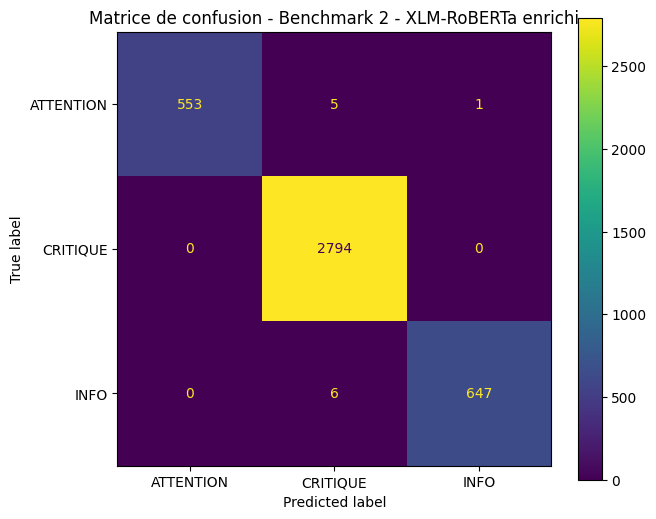

In [49]:
# Matrice de confusion Benchmark 2

cm_b2 = confusion_matrix(test_labels_b2, test_preds_b2)

disp_b2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_b2,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))
disp_b2.plot(ax=ax, values_format="d")
plt.title("Matrice de confusion - Benchmark 2 - XLM-RoBERTa enrichi")
plt.show()

niveau,ATTENTION,CRITIQUE,INFO
risk_decision,,,
no risk,0.000000,0.785340,0.214660
not serious,0.000000,0.307907,0.692093
potential risk,0.724849,0.275151,0.000000
potentially serious,0.520607,0.479393,0.000000
serious,0.000000,1.000000,0.000000
undecided,0.000000,0.442071,0.557929


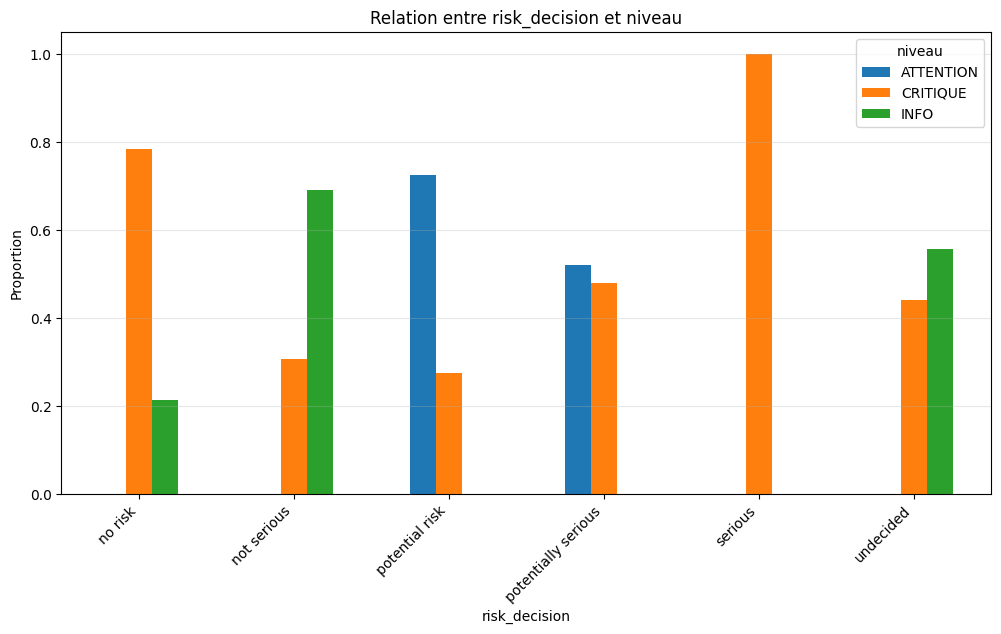

In [50]:
# Vérification data leakage

if "risk_decision" in df.columns:
    leakage_table = pd.crosstab(
        df["risk_decision"],
        df["niveau"],
        normalize="index"
    )

    display(leakage_table)

    leakage_table.plot(kind="bar", figsize=(12, 6))
    plt.title("Relation entre risk_decision et niveau")
    plt.xlabel("risk_decision")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# Interprétation du Benchmark 2

L'analyse croisée entre `risk_decision` et `niveau` montre une forte corrélation entre cette variable et la classe cible.

Par exemple, la modalité `serious` correspond à 100 % à la classe `CRITIQUE`, tandis que `potential risk` est majoritairement associé à la classe `ATTENTION` et `not serious` à la classe `INFO`.

Cette relation explique les performances presque parfaites du Benchmark 2. Toutefois, ces résultats doivent être interprétés avec prudence, car ils indiquent un risque élevé de data leakage.

Pour obtenir une évaluation plus réaliste de la capacité NLP du modèle, un troisième benchmark est proposé en supprimant la variable `risk_decision` de l'entrée du modèle.

In [51]:
# Benchmark 3 : entrée enrichie sans risk_decision

def build_model_input_b3(row):
    return (
        f"Texte alerte : {row.get('texte', '')}. "
        f"Catégorie produit : {row.get('category', '')}. "
        f"Type notification : {row.get('classification', '')}. "
        f"Pays origine : {row.get('origin', '')}."
    )

df["model_input_b3"] = df.apply(build_model_input_b3, axis=1)

display(df[["texte", "model_input_b3", "niveau"]].head())

,texte,model_input_b3,niveau
0,Salmonella spp. in sesame seeds from Nigeria |...,Texte alerte : Salmonella spp. in sesame seeds...,CRITIQUE
1,Salmonella in soya bean meal from Argentina | ...,Texte alerte : Salmonella in soya bean meal fr...,ATTENTION
2,Ciprodinilo en Mango de Colombia // Ciprodinil...,Texte alerte : Ciprodinilo en Mango de Colombi...,CRITIQUE
3,Consignment frozen fried bean curd skipped vet...,Texte alerte : Consignment frozen fried bean c...,INFO
4,Undeclared consignements of frozen strawberrie...,Texte alerte : Undeclared consignements of fro...,ATTENTION


In [52]:
# Split Benchmark 3


train_df_b3, temp_df_b3 = train_test_split(
    df,
    test_size=CFG.TEST_SIZE + CFG.VAL_SIZE,
    stratify=df["label"],
    random_state=CFG.SEED
)

relative_val_size = CFG.VAL_SIZE / (CFG.TEST_SIZE + CFG.VAL_SIZE)

val_df_b3, test_df_b3 = train_test_split(
    temp_df_b3,
    test_size=1 - relative_val_size,
    stratify=temp_df_b3["label"],
    random_state=CFG.SEED
)

train_df_b3 = train_df_b3.reset_index(drop=True)
val_df_b3 = val_df_b3.reset_index(drop=True)
test_df_b3 = test_df_b3.reset_index(drop=True)

print("Train Benchmark 3 :", train_df_b3.shape)
print("Validation Benchmark 3 :", val_df_b3.shape)
print("Test Benchmark 3 :", test_df_b3.shape)

Train Benchmark 3 : (18693, 13)
Validation Benchmark 3 : (4006, 13)
Test Benchmark 3 : (4006, 13)


In [53]:
# Datasets Benchmark 3

train_dataset_b3 = RASFFDataset(
    train_df_b3["model_input_b3"],
    train_df_b3["label"],
    tokenizer,
    CFG.MAX_LENGTH
)

val_dataset_b3 = RASFFDataset(
    val_df_b3["model_input_b3"],
    val_df_b3["label"],
    tokenizer,
    CFG.MAX_LENGTH
)

test_dataset_b3 = RASFFDataset(
    test_df_b3["model_input_b3"],
    test_df_b3["label"],
    tokenizer,
    CFG.MAX_LENGTH
)

print("Datasets Benchmark 3 prêts.")

Datasets Benchmark 3 prêts.


In [54]:
# Modèle Benchmark 3

model_b3 = AutoModelForSequenceClassification.from_pretrained(
    CFG.MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model_b3.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [61]:
# TrainingArguments Benchmark 3

training_args_b3 = TrainingArguments(
    output_dir="/kaggle/working/xlm_roberta_rasff_classifier_benchmark_3",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=CFG.LEARNING_RATE,
    per_device_train_batch_size=CFG.BATCH_SIZE,
    per_device_eval_batch_size=CFG.BATCH_SIZE,
    num_train_epochs=CFG.EPOCHS,
    weight_decay=CFG.WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
    seed=CFG.SEED
)

In [62]:
# Trainer Benchmark 3

trainer_b3 = Trainer(
    model=model_b3,
    args=training_args_b3,
    train_dataset=train_dataset_b3,
    eval_dataset=val_dataset_b3,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ]
)

In [63]:
# Entraînement Benchmark 3

train_result_b3 = trainer_b3.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,0.865807,0.726653,0.820020,0.788380,0.820020,0.783397
2,0.718364,0.671550,0.843485,0.828453,0.843485,0.832422
3,0.658273,0.672754,0.853220,0.838170,0.853220,0.839587


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SafetensorError: Error while serializing: I/O error: No space left on device (os error 28)

In [64]:
# =========================
# Cellule 49 — Vérification espace disque Kaggle
# =========================

!df -h /kaggle/working
!du -h -d 1 /kaggle/working | sort -hr | head -20

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   20G     0 100% /kaggle/working
20G	/kaggle/working
7.1G	/kaggle/working/xlm_roberta_rasff_classifier_benchmark_3
6.3G	/kaggle/working/xlm_roberta_rasff_classifier_benchmark_2
6.3G	/kaggle/working/xlm_roberta_rasff_classifier
16K	/kaggle/working/.virtual_documents


In [65]:
# Nettoyage espace disque - supprimer Benchmark 1 et 2

import os
import shutil
import gc
import torch

dirs_to_remove = [
    "/kaggle/working/xlm_roberta_rasff_classifier",
    "/kaggle/working/xlm_roberta_rasff_classifier_benchmark_2"
]

for d in dirs_to_remove:
    if os.path.exists(d):
        shutil.rmtree(d)
        print("Supprimé :", d)

gc.collect()
torch.cuda.empty_cache()

!df -h /kaggle/working

Supprimé : /kaggle/working/xlm_roberta_rasff_classifier
Supprimé : /kaggle/working/xlm_roberta_rasff_classifier_benchmark_2
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  7.1G   13G  36% /kaggle/working


In [66]:
# Supprimer Benchmark 3 incomplet

import os
import shutil
import gc
import torch

b3_dir = "/kaggle/working/xlm_roberta_rasff_classifier_benchmark_3"

if os.path.exists(b3_dir):
    shutil.rmtree(b3_dir)
    print("Supprimé :", b3_dir)

gc.collect()
torch.cuda.empty_cache()

!df -h /kaggle/working

Supprimé : /kaggle/working/xlm_roberta_rasff_classifier_benchmark_3
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   96K   20G   1% /kaggle/working


In [80]:
save_strategy="no"
load_best_model_at_end=False

In [81]:
# TrainingArguments Benchmark 3 corrigé

training_args_b3 = TrainingArguments(
    output_dir="/kaggle/working/xlm_roberta_rasff_classifier_benchmark_3_clean",
    eval_strategy="epoch",
    save_strategy="no",          # Important : pas de sauvegarde automatique
    logging_strategy="epoch",
    learning_rate=CFG.LEARNING_RATE,
    per_device_train_batch_size=CFG.BATCH_SIZE,
    per_device_eval_batch_size=CFG.BATCH_SIZE,
    num_train_epochs=3,
    weight_decay=CFG.WEIGHT_DECAY,
    load_best_model_at_end=False, # Important avec save_strategy="no"
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=CFG.SEED
)

In [82]:
# Modèle propre Benchmark 3

model_b3 = AutoModelForSequenceClassification.from_pretrained(
    CFG.MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model_b3.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [83]:
# Trainer Benchmark 3 corrigé

trainer_b3 = Trainer(
    model=model_b3,
    args=training_args_b3,
    train_dataset=train_dataset_b3,
    eval_dataset=val_dataset_b3,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [84]:
# Réentraînement Benchmark 3

train_result_b3 = trainer_b3.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,0.886725,0.727766,0.815277,0.778476,0.815277,0.785760
2,0.730347,0.724672,0.826011,0.795359,0.826011,0.790346
3,0.681224,0.707390,0.834748,0.817823,0.834748,0.814600


In [85]:
# Évaluation test Benchmark 3

test_predictions_b3 = trainer_b3.predict(test_dataset_b3)

test_logits_b3 = test_predictions_b3.predictions
test_labels_b3 = test_predictions_b3.label_ids
test_preds_b3 = np.argmax(test_logits_b3, axis=1)

test_report_b3 = classification_report(
    test_labels_b3,
    test_preds_b3,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

print(classification_report(
    test_labels_b3,
    test_preds_b3,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

   ATTENTION       0.48      0.17      0.25       559
    CRITIQUE       0.94      0.97      0.95      2794
        INFO       0.57      0.80      0.67       653

    accuracy                           0.83      4006
   macro avg       0.66      0.65      0.62      4006
weighted avg       0.81      0.83      0.81      4006



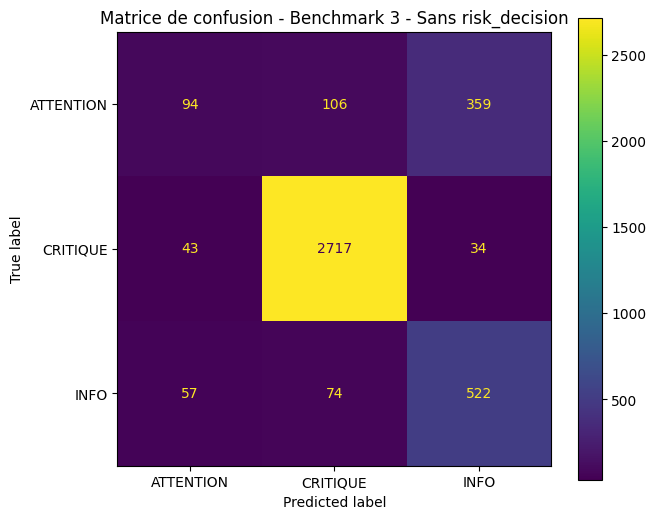

In [86]:
# Matrice de confusion Benchmark 3

cm_b3 = confusion_matrix(test_labels_b3, test_preds_b3)

disp_b3 = ConfusionMatrixDisplay(
    confusion_matrix=cm_b3,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))
disp_b3.plot(ax=ax, values_format="d")
plt.title("Matrice de confusion - Benchmark 3 - Sans risk_decision")
plt.show()

In [87]:
# Sauvegarde rapport Benchmark 3

benchmark_3_report_df = pd.DataFrame(test_report_b3).transpose()

display(benchmark_3_report_df)

benchmark_3_report_path = "/kaggle/working/benchmark_3_classification_report.csv"
benchmark_3_report_df.to_csv(benchmark_3_report_path, index=True)

print("Rapport Benchmark 3 sauvegardé :", benchmark_3_report_path)

,precision,recall,f1-score,support
ATTENTION,0.484536,0.168157,0.249668,559.000000
CRITIQUE,0.937867,0.972441,0.954841,2794.000000
INFO,0.570492,0.799387,0.665816,653.000000
accuracy,0.832002,0.832002,0.832002,0.832002
macro avg,0.664298,0.646662,0.623442,4006.000000
weighted avg,0.814725,0.832002,0.809328,4006.000000


Rapport Benchmark 3 sauvegardé : /kaggle/working/benchmark_3_classification_report.csv


In [88]:
# Comparaison Benchmark 1 vs Benchmark 3

benchmark_3_results = {
    "benchmark": "Benchmark 3 - XLM-RoBERTa enrichi sans risk_decision",
    "input_features": "texte + category + classification + origin",
    "accuracy": accuracy_score(test_labels_b3, test_preds_b3),
    "precision_weighted": precision_recall_fscore_support(
        test_labels_b3, test_preds_b3, average="weighted", zero_division=0
    )[0],
    "recall_weighted": precision_recall_fscore_support(
        test_labels_b3, test_preds_b3, average="weighted", zero_division=0
    )[1],
    "f1_weighted": precision_recall_fscore_support(
        test_labels_b3, test_preds_b3, average="weighted", zero_division=0
    )[2],
    "f1_macro": precision_recall_fscore_support(
        test_labels_b3, test_preds_b3, average="macro", zero_division=0
    )[2]
}

comparison_final_df = pd.DataFrame([
    benchmark_1_results,
    benchmark_3_results
])

display(comparison_final_df)

,benchmark,input_features,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,Benchmark 1 - XLM-RoBERTa avec texte seul,[texte],0.775087,0.752914,0.775087,0.757495,0.606016
1,Benchmark 3 - XLM-RoBERTa enrichi sans risk_de...,texte + category + classification + origin,0.832002,0.814725,0.832002,0.809328,0.623442


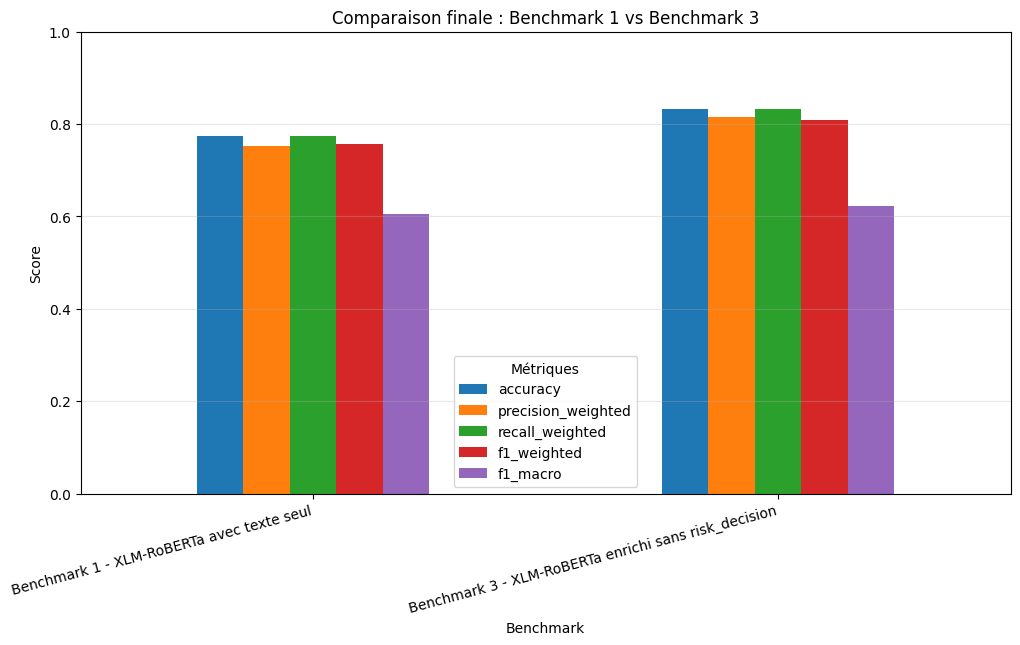

In [89]:
# Visualisation Benchmark 1 vs Benchmark 3


metrics_to_plot = [
    "accuracy",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "f1_macro"
]

comparison_plot_df = comparison_final_df.set_index("benchmark")[metrics_to_plot]

comparison_plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("Comparaison finale : Benchmark 1 vs Benchmark 3")
plt.xlabel("Benchmark")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Métriques")
plt.show()

In [78]:
# =========================
# Cellule 53.1 — Nettoyage mémoire GPU
# =========================

import gc
import torch

# Supprimer les anciens objets lourds si présents
objects_to_delete = [
    "model",
    "trainer",
    "model_b2",
    "trainer_b2",
    "model_b3",
    "trainer_b3",
    "train_result",
    "train_result_b2",
    "train_result_b3"
]

for obj in objects_to_delete:
    if obj in globals():
        del globals()[obj]
        print(f"Supprimé de la mémoire : {obj}")

gc.collect()
torch.cuda.empty_cache()

print("Mémoire GPU nettoyée.")

Supprimé de la mémoire : model
Supprimé de la mémoire : trainer
Supprimé de la mémoire : model_b2
Supprimé de la mémoire : trainer_b2
Supprimé de la mémoire : model_b3
Supprimé de la mémoire : trainer_b3
Supprimé de la mémoire : train_result
Supprimé de la mémoire : train_result_b2
Mémoire GPU nettoyée.


In [79]:
# Vérification GPU

!nvidia-smi

Mon May 25 17:24:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             29W /   70W |   11275MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Benchmark 4 — Correction du déséquilibre avec class weights

Le Benchmark 3 a amélioré les performances globales, mais la classe `ATTENTION` reste difficile à détecter.

Pour corriger ce problème, ce Benchmark 4 conserve la même entrée que Benchmark 3 :

- texte de l’alerte
- catégorie du produit
- type de notification
- pays d’origine

La différence principale est l’utilisation d’une fonction de perte pondérée afin de donner plus d’importance aux classes minoritaires pendant l’entraînement.

In [101]:
# =========================
# Cellule 66 — Nettoyage complet mémoire GPU avant Benchmark 4
# =========================

import gc
import torch

objects_to_delete = [
    "model",
    "trainer",
    "model_b2",
    "trainer_b2",
    "model_b3",
    "trainer_b3",
    "model_b4",
    "trainer_b4",
    "train_result",
    "train_result_b2",
    "train_result_b3",
    "train_result_b4",
    "test_predictions_b3",
    "test_logits_b3"
]

for obj in objects_to_delete:
    if obj in globals():
        del globals()[obj]
        print(f"Supprimé : {obj}")

gc.collect()
torch.cuda.empty_cache()

print("Mémoire GPU nettoyée.")
!nvidia-smi

Supprimé : model_b3
Supprimé : trainer_b3
Supprimé : model_b4
Supprimé : trainer_b4
Supprimé : train_result_b3
Supprimé : test_predictions_b3
Supprimé : test_logits_b3
Mémoire GPU nettoyée.
Mon May 25 18:15:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             31W /   70W 

In [91]:
# Calcul des poids de classes

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df_b3["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df_b3["label"]
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Classes :", classes)
print("Labels :", [id2label[int(c)] for c in classes])
print("Class weights :", class_weights)

Classes : [0 1 2]
Labels : ['ATTENTION', 'CRITIQUE', 'INFO']
Class weights : [2.39010357 0.47791072 2.04429134]


In [92]:
# Trainer personnalisé avec class weights

from torch import nn

class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        
        outputs = model(
            input_ids=inputs.get("input_ids"),
            attention_mask=inputs.get("attention_mask")
        )
        
        logits = outputs.get("logits")
        
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )
        
        return (loss, outputs) if return_outputs else loss

In [104]:
# Modèle Benchmark 4

model_b4 = AutoModelForSequenceClassification.from_pretrained(
    CFG.MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model_b4.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [105]:
# TrainingArguments Benchmark 4 léger

training_args_b4 = TrainingArguments(
    output_dir="/kaggle/working/xlm_roberta_rasff_classifier_benchmark_4",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    
    learning_rate=CFG.LEARNING_RATE,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    
    num_train_epochs=3,
    weight_decay=CFG.WEIGHT_DECAY,
    
    load_best_model_at_end=False,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=CFG.SEED
)

In [106]:
# Trainer Benchmark 4

trainer_b4 = WeightedLossTrainer(
    model=model_b4,
    args=training_args_b4,
    train_dataset=train_dataset_b3,
    eval_dataset=val_dataset_b3,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor
)

In [107]:

# Entraînement Benchmark 4

train_result_b4 = trainer_b4.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,2.406073,0.547191,0.823764,0.828643,0.823764,0.821919
2,2.087845,0.510355,0.845232,0.853645,0.845232,0.848184
3,1.943920,0.493767,0.841987,0.848445,0.841987,0.844803


In [108]:
# Évaluation test Benchmark 4

test_predictions_b4 = trainer_b4.predict(test_dataset_b3)

test_logits_b4 = test_predictions_b4.predictions
test_labels_b4 = test_predictions_b4.label_ids
test_preds_b4 = np.argmax(test_logits_b4, axis=1)

test_report_b4 = classification_report(
    test_labels_b4,
    test_preds_b4,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

print(classification_report(
    test_labels_b4,
    test_preds_b4,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

   ATTENTION       0.51      0.50      0.50       559
    CRITIQUE       0.97      0.93      0.95      2794
        INFO       0.62      0.72      0.67       653

    accuracy                           0.84      4006
   macro avg       0.70      0.72      0.71      4006
weighted avg       0.85      0.84      0.84      4006



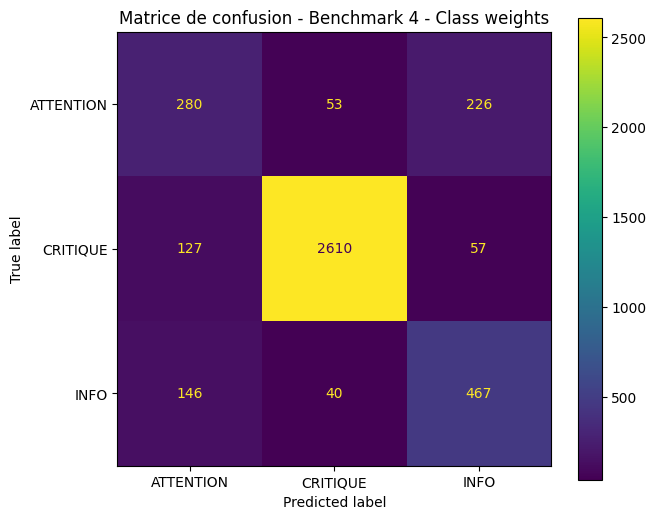

In [109]:
# Matrice de confusion Benchmark 4

cm_b4 = confusion_matrix(test_labels_b4, test_preds_b4)

disp_b4 = ConfusionMatrixDisplay(
    confusion_matrix=cm_b4,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))
disp_b4.plot(ax=ax, values_format="d")
plt.title("Matrice de confusion - Benchmark 4 - Class weights")
plt.show()

In [110]:
# Rapport détaillé Benchmark 4

benchmark_4_report_df = pd.DataFrame(test_report_b4).transpose()

display(benchmark_4_report_df)

benchmark_4_report_path = "/kaggle/working/benchmark_4_classification_report.csv"
benchmark_4_report_df.to_csv(benchmark_4_report_path, index=True)

print("Rapport Benchmark 4 sauvegardé :", benchmark_4_report_path)

,precision,recall,f1-score,support
ATTENTION,0.506329,0.500894,0.503597,559.000000
CRITIQUE,0.965594,0.934145,0.949609,2794.000000
INFO,0.622667,0.715161,0.665716,653.000000
accuracy,0.837993,0.837993,0.837993,0.837993
macro avg,0.698197,0.716733,0.706307,4006.000000
weighted avg,0.845609,0.837993,0.841096,4006.000000


Rapport Benchmark 4 sauvegardé : /kaggle/working/benchmark_4_classification_report.csv


In [111]:
# Comparaison Benchmark 1 / 3 / 4

benchmark_4_results = {
    "benchmark": "Benchmark 4 - XLM-RoBERTa + class weights",
    "input_features": "texte + category + classification + origin",
    "accuracy": accuracy_score(test_labels_b4, test_preds_b4),
    "precision_weighted": precision_recall_fscore_support(
        test_labels_b4, test_preds_b4, average="weighted", zero_division=0
    )[0],
    "recall_weighted": precision_recall_fscore_support(
        test_labels_b4, test_preds_b4, average="weighted", zero_division=0
    )[1],
    "f1_weighted": precision_recall_fscore_support(
        test_labels_b4, test_preds_b4, average="weighted", zero_division=0
    )[2],
    "f1_macro": precision_recall_fscore_support(
        test_labels_b4, test_preds_b4, average="macro", zero_division=0
    )[2],
    "f1_attention": benchmark_4_report_df.loc["ATTENTION", "f1-score"],
    "recall_attention": benchmark_4_report_df.loc["ATTENTION", "recall"]
}

benchmark_1_results_extended = benchmark_1_results.copy()
benchmark_1_results_extended["f1_attention"] = benchmark_1_report_df.loc["ATTENTION", "f1-score"]
benchmark_1_results_extended["recall_attention"] = benchmark_1_report_df.loc["ATTENTION", "recall"]

benchmark_3_results_extended = benchmark_3_results.copy()
benchmark_3_results_extended["f1_attention"] = benchmark_3_report_df.loc["ATTENTION", "f1-score"]
benchmark_3_results_extended["recall_attention"] = benchmark_3_report_df.loc["ATTENTION", "recall"]

comparison_benchmarks_df = pd.DataFrame([
    benchmark_1_results_extended,
    benchmark_3_results_extended,
    benchmark_4_results
])

display(comparison_benchmarks_df)

,benchmark,input_features,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,f1_attention,recall_attention
0,Benchmark 1 - XLM-RoBERTa avec texte seul,[texte],0.775087,0.752914,0.775087,0.757495,0.606016,0.389016,0.304114
1,Benchmark 3 - XLM-RoBERTa enrichi sans risk_de...,texte + category + classification + origin,0.832002,0.814725,0.832002,0.809328,0.623442,0.249668,0.168157
2,Benchmark 4 - XLM-RoBERTa + class weights,texte + category + classification + origin,0.837993,0.845609,0.837993,0.841096,0.706307,0.503597,0.500894


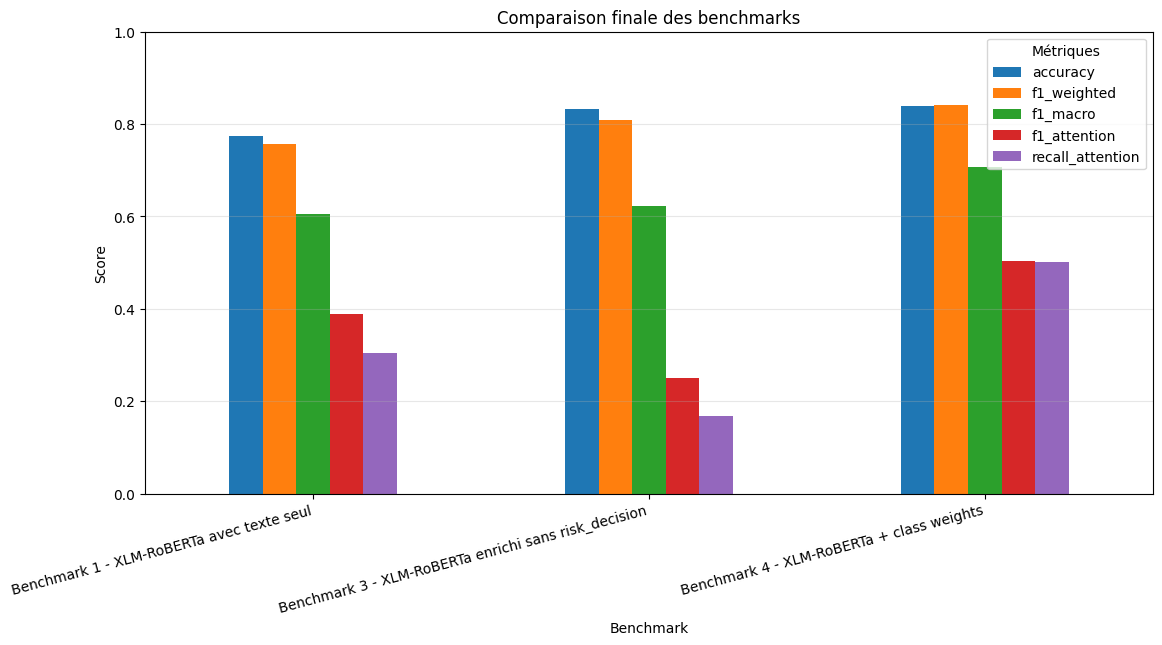

In [112]:
# Visualisation finale Benchmark 1 / 3 / 4

metrics_to_plot = [
    "accuracy",
    "f1_weighted",
    "f1_macro",
    "f1_attention",
    "recall_attention"
]

comparison_plot_df = comparison_benchmarks_df.set_index("benchmark")[metrics_to_plot]

comparison_plot_df.plot(kind="bar", figsize=(13, 6))

plt.title("Comparaison finale des benchmarks")
plt.xlabel("Benchmark")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Métriques")
plt.show()

In [113]:
!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  112K   20G   1% /kaggle/working


In [114]:
# Sauvegarde du modèle final Benchmark 4

BEST_MODEL_DIR = "/kaggle/working/best_rasff_classifier_benchmark_4"

trainer_b4.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

with open(os.path.join(BEST_MODEL_DIR, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump(
        {
            "id2label": id2label,
            "label2id": label2id
        },
        f,
        ensure_ascii=False,
        indent=4
    )

print("Modèle final sauvegardé dans :", BEST_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle final sauvegardé dans : /kaggle/working/best_rasff_classifier_benchmark_4


# Module NER hybride

Le dataset utilisé ne contient pas d’annotations token-level au format BIO, nécessaires pour entraîner un modèle NER supervisé.

Pour cette raison, nous adoptons une approche hybride basée sur :

- le parsing du format semi-structuré RASFF ;
- les séparateurs `|` ;
- des expressions régulières ;
- des dictionnaires de pays ;
- des règles métier pour extraire les produits, dangers et dates.

Cette approche est adaptée au projet car les alertes RASFF suivent souvent une structure proche de :

`titre | catégorie produit | danger | pays`

In [138]:
# Ressources NER hybride

import pycountry
from collections import Counter

# Liste des pays
countries = [country.name for country in pycountry.countries]

# Ajouts utiles non toujours présents dans pycountry
additional_countries = [
    "Kosovo",
    "South Korea",
    "North Korea",
    "Great Britain",
    "United Kingdom",
    "Netherlands",
    "Vietnam",
    "Morocco",
    "Czech Republic",
    "Bosnia and Herzegovina"
]

countries = sorted(set(countries + additional_countries), key=len, reverse=True)

# Dangers fréquents dans RASFF
danger_keywords = [
    "Salmonella",
    "Listeria monocytogenes",
    "Listeria",
    "hepatitis A virus",
    "norovirus",
    "Aflatoxin",
    "Aflatoxin B1",
    "ochratoxin A",
    "pesticide residues",
    "mycotoxins",
    "pathogenic micro-organisms",
    "non-pathogenic micro-organisms",
    "heavy metals",
    "foreign bodies",
    "allergen",
    "undeclared allergen",
    "glass",
    "plastic",
    "metal",
    "nitrate",
    "cyprodinil",
    "carbofuran",
    "chlorpyrifos",
    "fipronil",
    "acetamiprid",
    "clothianidin",
    "dinotefuran",
    "ethion",
    "omethoate",
    "lead",
    "mercury",
    "cadmium"
]

# Ajouter des dangers supplémentaires détectés dans le dataset
extra_danger_keywords = [
    "cannabidiol",
    "CBD",
    "benzo(a)pyrene",
    "PAH4",
    "polycyclic aromatic hydrocarbons",
    "unauthorized novel food ingredient",
    "novel food ingredient",
    "aflatoxins",
    "Aflatoxins B1",
    "difenoconazole",
    "fluopyram",
    "pyraclostrobin",
    "tebuconazole",
    "acetamiprid",
    "chlorpyrifos",
    "Salmonella infantis",
    "Salmonella enteritidis"
]

danger_keywords = sorted(
    set(danger_keywords + extra_danger_keywords),
    key=len,
    reverse=True
)
print("Nombre de pays :", len(countries))
print("Nombre de mots-clés danger :", len(danger_keywords))

Nombre de pays : 255
Nombre de mots-clés danger : 47


In [141]:
# Parsing du texte RASFF

def split_rasff_text(text):
    """
    Sépare une alerte RASFF selon le format :
    titre | catégorie produit | danger | pays
    """
    text = clean_text(text)
    parts = [p.strip() for p in text.split("|")]
    
    while len(parts) < 4:
        parts.append("")
    
    return {
        "title": parts[0],
        "category": parts[1],
        "hazard_raw": parts[2],
        "origin": parts[-1]
    }

def extract_origin_country(text):
    """
    Extrait le pays d'origine principal depuis le dernier segment après le dernier séparateur |.
    """
    parts = split_rasff_text(text)
    origin = parts["origin"]
    
    if origin:
        return [origin]
    
    return []
# Test rapide
example = df["texte"].iloc[0]
print(example)
print(split_rasff_text(example))

Salmonella spp. in sesame seeds from Nigeria | nuts, nut products and seeds | Salmonella - {pathogenic micro-organisms} | Nigeria
{'title': 'Salmonella spp. in sesame seeds from Nigeria', 'category': 'nuts, nut products and seeds', 'hazard_raw': 'Salmonella - {pathogenic micro-organisms}', 'origin': 'Nigeria'}


In [118]:
# Extraction des pays

def extract_countries(text):
    """
    Extrait les pays présents dans le texte.
    """
    text = clean_text(text)
    found = []
    
    for country in countries:
        pattern = r"\b" + re.escape(country) + r"\b"
        if re.search(pattern, text, flags=re.IGNORECASE):
            found.append(country)
    
    return list(dict.fromkeys(found))


# Test
print(extract_countries(example))

['Nigeria']


In [119]:
# Extraction des dates

def extract_dates(text):
    """
    Extrait les dates ou années mentionnées dans le texte.
    """
    text = clean_text(text)
    
    patterns = [
        r"\b\d{4}\b",
        r"\b\d{1,2}/\d{1,2}/\d{2,4}\b",
        r"\b\d{1,2}-\d{1,2}-\d{2,4}\b",
        r"\b(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{4}\b"
    ]
    
    dates = []
    
    for pattern in patterns:
        dates.extend(re.findall(pattern, text, flags=re.IGNORECASE))
    
    return list(dict.fromkeys(dates))


# Test
print(extract_dates(example))

[]


In [120]:
# Extraction des dangers

def extract_dangers(text):
    """
    Extrait les dangers :
    - contenu entre accolades {...}
    - substances avant les tirets
    - mots-clés connus
    """
    parts = split_rasff_text(text)
    hazard_raw = parts["hazard_raw"]
    
    dangers = []
    
    # Extraction des catégories entre accolades
    brace_content = re.findall(r"\{([^}]+)\}", hazard_raw)
    dangers.extend([d.strip() for d in brace_content if d.strip()])
    
    # Extraction des substances avant ou autour des tirets
    hazard_items = re.split(r",", hazard_raw)
    
    for item in hazard_items:
        item = re.sub(r"\{[^}]+\}", "", item)
        item = item.replace("-", " ")
        item = item.replace("unauthorised substance", "")
        item = item.replace("too high content", "")
        item = clean_text(item)
        
        if len(item) > 2:
            dangers.append(item)
    
    # Extraction par mots-clés
    for keyword in danger_keywords:
        pattern = r"\b" + re.escape(keyword) + r"\b"
        if re.search(pattern, text, flags=re.IGNORECASE):
            dangers.append(keyword)
    
    dangers = [d.strip() for d in dangers if len(d.strip()) > 2]
    
    return list(dict.fromkeys(dangers))


# Test
print(extract_dangers(example))

['pathogenic micro-organisms', 'Salmonella']


In [139]:
# 85 — Extraction des produits améliorée

def clean_product_name(product):
    """
    Nettoie un nom de produit extrait depuis le titre.
    """
    product = clean_text(product)
    
    # Supprimer les préfixes fréquents qui ne sont pas des produits
    prefixes = [
        r"^pesticides?\s+in\s+",
        r"^pesticide residues?\s+in\s+",
        r"^aflatoxins?\s+in\s+",
        r"^salmonella\s+in\s+",
        r"^detection\s+of\s+",
        r"^detection\s+of\s+salmonella\s+\w+\s+on\s+",
        r"^detection\s+of\s+salmonella\s+\w+\s+in\s+",
        r"^unauthorized\s+novel\s+food\s+ingredient\s+",
        r"^unauthorised\s+novel\s+food\s+ingredient\s+",
        r"^elevated\s+levels\s+of\s+.*?\s+in\s+",
        r"^chlorpyrifos\s+detected\s+in\s+",
        r"^acetamiprid\s+in\s+",
        r"^too\s+much\s+",
        r"^presence\s+of\s+",
        r"^foreign\s+bodies\s+in\s+",
        r"^undeclared\s+allergen\s+\w+\s+on\s+",
        r"^undeclared\s+allergen\s+",
    ]
    
    for prefix in prefixes:
        product = re.sub(prefix, "", product, flags=re.IGNORECASE)
    
    # Supprimer les bouts trop génériques
    product = re.sub(r"\s+via\s+.*$", "", product, flags=re.IGNORECASE)
    product = re.sub(r"\s+from\s+.*$", "", product, flags=re.IGNORECASE)
    
    product = clean_text(product)
    
    return product


def extract_products(text):
    """
    Extrait les produits ou catégories de produits depuis :
    - la catégorie RASFF ;
    - le titre de l'alerte.
    """
    parts = split_rasff_text(text)
    
    title = parts["title"]
    category = parts["category"]
    
    products = []
    
    # 1. Ajouter la catégorie officielle
    if category:
        products.append(category)
    
    # 2. Extraire la partie avant "from"
    if " from " in title.lower():
        candidate = re.split(r"\s+from\s+", title, flags=re.IGNORECASE)[0]
        candidate = clean_product_name(candidate)
        if len(candidate) > 2:
            products.append(candidate)
    
    # 3. Patterns ciblés
    product_patterns = [
        r"in ([a-zA-Z\s\-\(\)]+?) from",
        r"on ([a-zA-Z\s\-\(\)]+?) from",
        r"of ([a-zA-Z\s\-\(\)]+?) from",
    ]
    
    for pattern in product_patterns:
        matches = re.findall(pattern, title, flags=re.IGNORECASE)
        
        for match in matches:
            match = clean_product_name(match)
            
            if len(match) > 2:
                products.append(match)
    
    # 4. Nettoyage final
    stop_products = [
        "detection",
        "presence",
        "too much",
        "border rejection",
        "consignment",
        "pesticides",
        "pesticide residues",
        "aflatoxins",
        "salmonella",
        "chlorpyrifos",
        "acetamiprid"
    ]
    
    cleaned_products = []
    
    for p in products:
        p = clean_product_name(p)
        
        if len(p) <= 2:
            continue
        
        if p.lower() in stop_products:
            continue
        
        cleaned_products.append(p)
    
    return list(dict.fromkeys(cleaned_products))


# Test
print(example)
print(extract_products(example))

Salmonella spp. in sesame seeds from Nigeria | nuts, nut products and seeds | Salmonella - {pathogenic micro-organisms} | Nigeria
['nuts, nut products and seeds', 'Salmonella spp. in sesame seeds', 'sesame seeds']


In [142]:
# Fonction finale NER

def extract_entities(text):
    """
    Fonction principale du module NER hybride.
    """
    countries_mentioned = extract_countries(text)
    origin_country = extract_origin_country(text)
    
    return {
        "pays": countries_mentioned,
        "pays_origine": origin_country,
        "produits": extract_products(text),
        "dates": extract_dates(text),
        "danger": extract_dangers(text)
    }

# Test complet
entities_example = extract_entities(example)

print(example)
print(json.dumps(entities_example, indent=4, ensure_ascii=False))

Salmonella spp. in sesame seeds from Nigeria | nuts, nut products and seeds | Salmonella - {pathogenic micro-organisms} | Nigeria
{
    "pays": [
        "Nigeria"
    ],
    "pays_origine": [
        "Nigeria"
    ],
    "produits": [
        "nuts, nut products and seeds",
        "Salmonella spp. in sesame seeds",
        "sesame seeds"
    ],
    "dates": [],
    "danger": [
        "pathogenic micro-organisms",
        "Salmonella"
    ]
}


In [123]:
# Application NER sur échantillon

sample_ner_df = df.sample(10, random_state=CFG.SEED).copy()

sample_ner_df["entities"] = sample_ner_df["texte"].apply(extract_entities)
sample_ner_df["pays_extraits"] = sample_ner_df["entities"].apply(lambda x: x["pays"])
sample_ner_df["produits_extraits"] = sample_ner_df["entities"].apply(lambda x: x["produits"])
sample_ner_df["dangers_extraits"] = sample_ner_df["entities"].apply(lambda x: x["danger"])
sample_ner_df["dates_extraites"] = sample_ner_df["entities"].apply(lambda x: x["dates"])

display(sample_ner_df[[
    "texte",
    "niveau",
    "pays_extraits",
    "produits_extraits",
    "dangers_extraits",
    "dates_extraites"
]])

,texte,niveau,pays_extraits,produits_extraits,dangers_extraits,dates_extraites
866,Pesticides in matcha tea from Japan | herbs an...,CRITIQUE,[Japan],"[herbs and spices, matcha tea, Pesticides in m...","[pesticide residues, difenoconazole, dinotefur...",[]
25524,"Aflatoxins in raw pistachio | nuts, nut produc...",CRITIQUE,[],"[nuts, nut products and seeds]","[mycotoxins, Aflatoxin B1, Aflatoxins B1, Afla...",[]
24343,Salmonella in Lamb Meal | feed materials | Sal...,INFO,[New Zealand],[feed materials],"[pathogenic micro-organisms, Salmonella enteri...",[]
17962,Detection of Salmonella Infantis on chiken mea...,CRITIQUE,[Spain],[poultry meat and poultry meat products],"[pathogenic micro-organisms, Salmonella infant...",[]
23206,aflatoxins in spice mix from Pakistan | herbs ...,CRITIQUE,[Pakistan],"[herbs and spices, spice mix, aflatoxins in sp...","[mycotoxins, Aflatoxin B1, Aflatoxin]",[]
18424,Acetamiprid in fresh prepper from Turkey | fru...,CRITIQUE,[Türkiye],"[fruits and vegetables, fresh prepper, Acetami...","[pesticide residues, acetamiprid]",[]
8589,Unauthorized novel food ingredient cannabidiol...,ATTENTION,[Cyprus],"[dietetic foods, food supplements and fortifie...",[],[]
3616,Chlorpyrifos detected in cloves from France | ...,CRITIQUE,"[Portugal, Poland, France]","[soups, broths, sauces and condiments, cloves,...","[pesticide residues, chlorpyrifos]",[]
4186,Elevated levels of benzo(a)pyrene and PAH4 in ...,ATTENTION,[Poland],"[meat and meat products (other than poultry), ...","[environmental pollutants, benzo(a)pyrene, pol...",[]
12215,Salmonella Infantis in fresh chicken breast fr...,ATTENTION,[Netherlands],"[poultry meat and poultry meat products, fresh...","[pathogenic micro-organisms, Salmonella infant...",[]


,pays,frequence
0,Türkiye,2349
1,Netherlands,2121
2,Poland,2016
3,China,1871
4,India,1809
5,Germany,1596
6,France,1590
7,Spain,1318
8,Italy,1237
9,Belgium,985


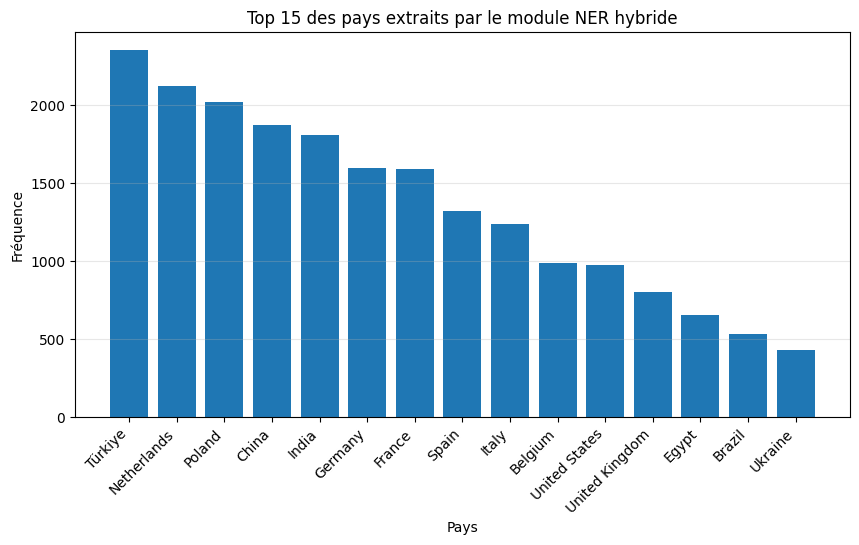

In [124]:
# Visualisation pays extraits

df_ner = df.copy()
df_ner["entities"] = df_ner["texte"].apply(extract_entities)
df_ner["pays_extraits"] = df_ner["entities"].apply(lambda x: x["pays"])
df_ner["produits_extraits"] = df_ner["entities"].apply(lambda x: x["produits"])
df_ner["dangers_extraits"] = df_ner["entities"].apply(lambda x: x["danger"])

all_countries_extracted = []

for pays_list in df_ner["pays_extraits"]:
    all_countries_extracted.extend(pays_list)

country_counts = Counter(all_countries_extracted)

country_ner_df = pd.DataFrame(
    country_counts.most_common(15),
    columns=["pays", "frequence"]
)

display(country_ner_df)

plt.figure(figsize=(10, 5))
plt.bar(country_ner_df["pays"], country_ner_df["frequence"])
plt.title("Top 15 des pays extraits par le module NER hybride")
plt.xlabel("Pays")
plt.ylabel("Fréquence")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

,danger,frequence
0,pathogenic micro-organisms,5587
1,pesticide residues,5270
2,Salmonella,3942
3,mycotoxins,2595
4,Aflatoxin,1970
5,Aflatoxin B1,1722
6,chlorpyrifos,1681
7,aflatoxin total,1230
8,heavy metals,1040
9,Listeria,917


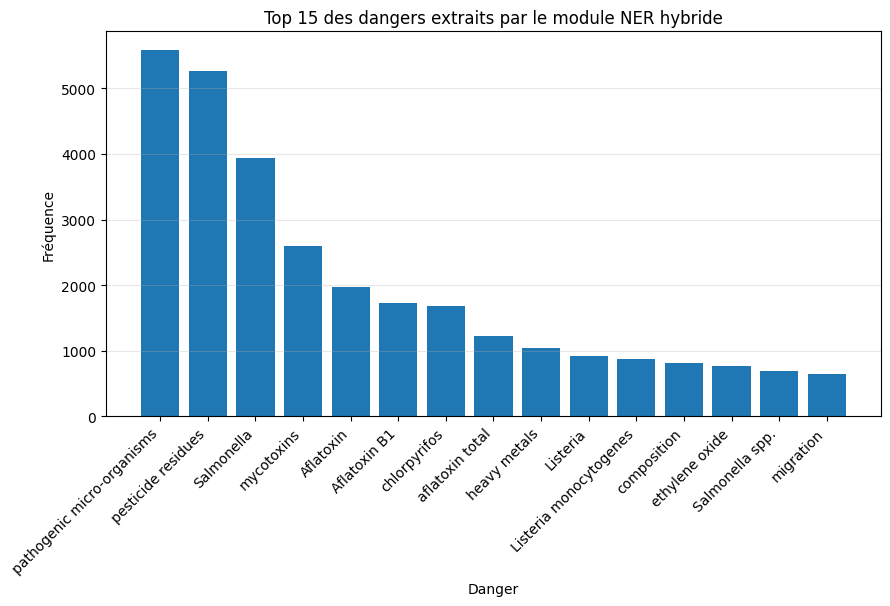

In [125]:
# Visualisation dangers extraits

all_dangers_extracted = []

for danger_list in df_ner["dangers_extraits"]:
    all_dangers_extracted.extend(danger_list)

danger_counts = Counter(all_dangers_extracted)

danger_ner_df = pd.DataFrame(
    danger_counts.most_common(15),
    columns=["danger", "frequence"]
)

display(danger_ner_df)

plt.figure(figsize=(10, 5))
plt.bar(danger_ner_df["danger"], danger_ner_df["frequence"])
plt.title("Top 15 des dangers extraits par le module NER hybride")
plt.xlabel("Danger")
plt.ylabel("Fréquence")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

,produit,frequence
0,fruits and vegetables,4725
1,"nuts, nut products and seeds",2527
2,poultry meat and poultry meat products,2151
3,"dietetic foods, food supplements and fortified...",2071
4,cereals and bakery products,1766
5,herbs and spices,1697
6,fish and fish products,1487
7,meat and meat products (other than poultry),1235
8,other food product / mixed,1154
9,food contact materials,1146


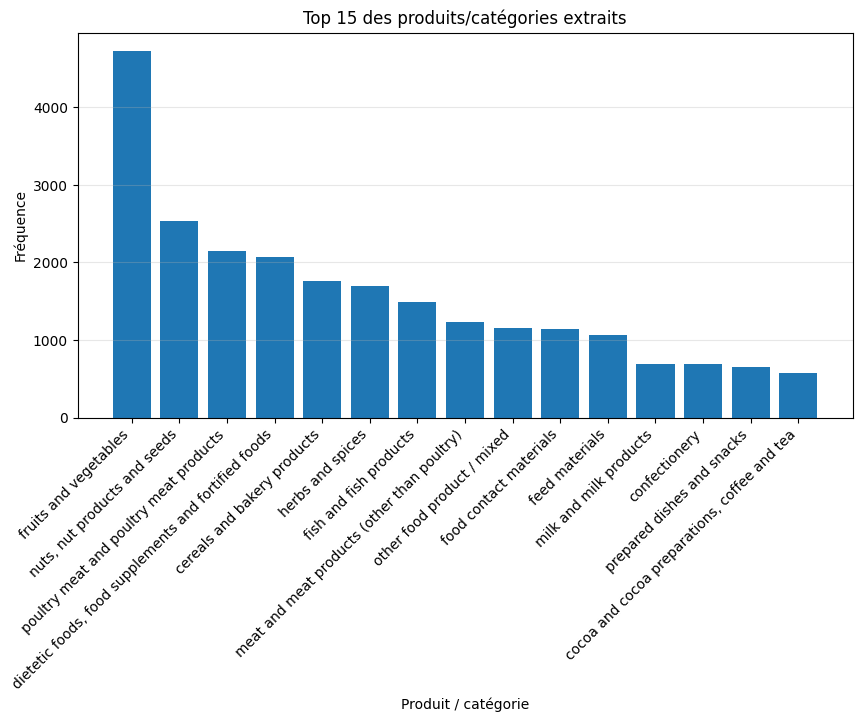

In [127]:
# Visualisation produits extraits

all_products_extracted = []

for product_list in df_ner["produits_extraits"]:
    all_products_extracted.extend(product_list)

product_counts = Counter(all_products_extracted)

product_ner_df = pd.DataFrame(
    product_counts.most_common(15),
    columns=["produit", "frequence"]
)

display(product_ner_df)

plt.figure(figsize=(10, 5))
plt.bar(product_ner_df["produit"], product_ner_df["frequence"])
plt.title("Top 15 des produits/catégories extraits")
plt.xlabel("Produit / catégorie")
plt.ylabel("Fréquence")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [128]:
# Résumé automatique FR

def generate_french_summary(text, niveau, entities, maroc_relevant=None):
    """
    Génère un résumé court en français à partir :
    - du niveau prédit ;
    - des entités extraites ;
    - de la pertinence Maroc si disponible.
    """
    pays = ", ".join(entities.get("pays", [])) if entities.get("pays") else "un pays non identifié"
    produits = ", ".join(entities.get("produits", [])) if entities.get("produits") else "un produit non identifié"
    dangers = ", ".join(entities.get("danger", [])) if entities.get("danger") else "un danger non spécifié"
    
    summary = (
        f"Une alerte de niveau {niveau} concerne {produits}. "
        f"Le danger identifié est : {dangers}. "
        f"Le pays concerné est {pays}."
    )
    
    if maroc_relevant is not None:
        try:
            if int(maroc_relevant) == 1:
                summary += " Cette alerte est pertinente pour le contexte marocain."
            else:
                summary += " Cette alerte présente une pertinence limitée pour le contexte marocain."
        except:
            pass
    
    return summary


# Test
summary_example = generate_french_summary(
    text=example,
    niveau="CRITIQUE",
    entities=extract_entities(example),
    maroc_relevant=1
)

print(summary_example)

Une alerte de niveau CRITIQUE concerne nuts, nut products and seeds, sesame seeds, in sesame seeds. Le danger identifié est : pathogenic micro-organisms, Salmonella. Le pays concerné est Nigeria. Cette alerte est pertinente pour le contexte marocain.


In [129]:
# Brief exécutif PME marocaines

def generate_executive_brief(text, niveau, entities, maroc_relevant=None):
    """
    Génère un brief exécutif orienté PME marocaines.
    """
    pays = ", ".join(entities.get("pays", [])) if entities.get("pays") else "un pays non identifié"
    produits = ", ".join(entities.get("produits", [])) if entities.get("produits") else "un produit non identifié"
    dangers = ", ".join(entities.get("danger", [])) if entities.get("danger") else "un danger non spécifié"
    
    if niveau == "CRITIQUE":
        impact = (
            "Cette alerte représente un risque élevé pour les PME marocaines, "
            "notamment en matière de conformité sanitaire, de contrôle qualité "
            "et de réputation commerciale."
        )
        recommendation = (
            "Il est recommandé de renforcer les contrôles qualité, "
            "la traçabilité fournisseur, les certificats sanitaires et les analyses laboratoire "
            "avant toute opération d'importation ou de distribution."
        )
    
    elif niveau == "ATTENTION":
        impact = (
            "Cette alerte indique un risque potentiel nécessitant une surveillance renforcée. "
            "Elle peut concerner des produits ou fournisseurs à contrôler avec prudence."
        )
        recommendation = (
            "Il est conseillé de vérifier les documents réglementaires, "
            "les seuils de conformité, l'historique du fournisseur et les alertes similaires."
        )
    
    else:
        impact = (
            "Cette alerte présente principalement un intérêt informationnel. "
            "Elle reste utile pour la veille réglementaire et l'anticipation des exigences du marché."
        )
        recommendation = (
            "Il est recommandé de conserver cette information dans le système de veille "
            "et de surveiller l'évolution des alertes liées au même produit ou pays."
        )
    
    maroc_sentence = ""
    
    if maroc_relevant is not None:
        try:
            if int(maroc_relevant) == 1:
                maroc_sentence = (
                    " L'alerte est pertinente pour les PME marocaines, car elle peut concerner "
                    "des produits, marchés ou risques liés aux échanges commerciaux du Maroc."
                )
            else:
                maroc_sentence = (
                    " L'impact direct sur les PME marocaines semble limité, mais l'information "
                    "reste utile dans une logique de veille stratégique."
                )
        except:
            pass
    
    brief = (
        f"Brief exécutif :\n"
        f"- Niveau de risque : {niveau}\n"
        f"- Produit concerné : {produits}\n"
        f"- Pays concerné : {pays}\n"
        f"- Danger identifié : {dangers}\n"
        f"- Impact potentiel : {impact}{maroc_sentence}\n"
        f"- Recommandation : {recommendation}"
    )
    
    return brief


# Test
brief_example = generate_executive_brief(
    text=example,
    niveau="CRITIQUE",
    entities=extract_entities(example),
    maroc_relevant=1
)

print(brief_example)

Brief exécutif :
- Niveau de risque : CRITIQUE
- Produit concerné : nuts, nut products and seeds, sesame seeds, in sesame seeds
- Pays concerné : Nigeria
- Danger identifié : pathogenic micro-organisms, Salmonella
- Impact potentiel : Cette alerte représente un risque élevé pour les PME marocaines, notamment en matière de conformité sanitaire, de contrôle qualité et de réputation commerciale. L'alerte est pertinente pour les PME marocaines, car elle peut concerner des produits, marchés ou risques liés aux échanges commerciaux du Maroc.
- Recommandation : Il est recommandé de renforcer les contrôles qualité, la traçabilité fournisseur, les certificats sanitaires et les analyses laboratoire avant toute opération d'importation ou de distribution.


In [131]:
# Construction input final

def build_final_model_input(text, category="", classification="", origin=""):
    """
    Construit l'entrée utilisée par le modèle final Benchmark 4.
    """
    return (
        f"Texte alerte : {clean_text(text)}. "
        f"Catégorie produit : {clean_text(category)}. "
        f"Type notification : {clean_text(classification)}. "
        f"Pays origine : {clean_text(origin)}."
    )

In [133]:
# Fonction de prédiction finale

def predict_risk_level_final(text, category="", classification="", origin=""):
    """
    Prédit le niveau de risque avec le modèle final Benchmark 4.
    """
    model_input = build_final_model_input(
        text=text,
        category=category,
        classification=classification,
        origin=origin
    )
    
    model_b4.eval()
    
    inputs = tokenizer(
        model_input,
        truncation=True,
        padding="max_length",
        max_length=CFG.MAX_LENGTH,
        return_tensors="pt"
    )
    
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model_b4(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]
    
    pred_id = int(np.argmax(probabilities))
    pred_label = id2label[pred_id]
    confidence = float(probabilities[pred_id])
    
    return pred_label, confidence, probabilities

In [134]:
# Pipeline complet final

def analyze_regulatory_alert(
    text,
    category="",
    classification="",
    origin="",
    maroc_relevant=None
):
    """
    Pipeline complet :
    1. Classification du niveau de risque
    2. Extraction des entités
    3. Résumé automatique FR
    4. Brief exécutif PME marocaines
    """
    niveau, confidence, probabilities = predict_risk_level_final(
        text=text,
        category=category,
        classification=classification,
        origin=origin
    )
    
    entities = extract_entities(text)
    
    # Si origin est donné mais pas extrait dans le texte, on l'ajoute
    if origin and origin not in entities["pays"]:
        entities["pays"].append(origin)
    
    # Si category est donnée mais pas extraite, on l'ajoute comme produit
    if category and category not in entities["produits"]:
        entities["produits"].append(category)
    
    resume_fr = generate_french_summary(
        text=text,
        niveau=niveau,
        entities=entities,
        maroc_relevant=maroc_relevant
    )
    
    brief_executif = generate_executive_brief(
        text=text,
        niveau=niveau,
        entities=entities,
        maroc_relevant=maroc_relevant
    )
    
    result = {
        "niveau": niveau,
        "confidence": round(confidence, 4),
        "probabilities": {
            id2label[i]: round(float(prob), 4)
            for i, prob in enumerate(probabilities)
        },
        "entities": entities,
        "resume_fr": resume_fr,
        "brief_executif": brief_executif
    }
    
    return result

In [135]:
# Test pipeline complet

test_row = df.sample(1, random_state=10).iloc[0]

test_text = test_row["texte"]
test_category = test_row.get("category", "")
test_classification = test_row.get("classification", "")
test_origin = test_row.get("origin", "")
test_maroc_relevant = test_row.get("maroc_relevant", None)

analysis_result = analyze_regulatory_alert(
    text=test_text,
    category=test_category,
    classification=test_classification,
    origin=test_origin,
    maroc_relevant=test_maroc_relevant
)

print("Texte :")
print(test_text)

print("\nRésultat complet :")
print(json.dumps(analysis_result, indent=4, ensure_ascii=False))

Texte :
Salmonella enterica ser. Senftenberg in chilled chicken legs from Poland with raw material from Hungary, used to produce frozen chicken kebab from Czech Republic | poultry meat and poultry meat products | Salmonella Senftenberg - {pathogenic micro-organisms} | Czechia,Hungary,Poland

Résultat complet :
{
    "niveau": "INFO",
    "confidence": 0.5679,
    "probabilities": {
        "ATTENTION": 0.4225,
        "CRITIQUE": 0.0095,
        "INFO": 0.5679
    },
    "entities": {
        "pays": [
            "Czech Republic",
            "Czechia",
            "Hungary",
            "Poland",
            "Czechia,Hungary,Poland"
        ],
        "produits": [
            "poultry meat and poultry meat products",
            "chilled chicken legs",
            "Senftenberg in chilled chicken legs",
            "Poland with raw material",
            "used to produce frozen chicken kebab"
        ],
        "dates": [],
        "danger": [
            "pathogenic micro-organisms"

In [136]:
# Analyse batch

def analyze_batch(dataframe, n=10):
    """
    Analyse plusieurs alertes depuis un DataFrame.
    """
    results = []
    
    sample_df = dataframe.head(n).copy()
    
    for _, row in sample_df.iterrows():
        result = analyze_regulatory_alert(
            text=row.get("texte", ""),
            category=row.get("category", ""),
            classification=row.get("classification", ""),
            origin=row.get("origin", ""),
            maroc_relevant=row.get("maroc_relevant", None)
        )
        
        results.append({
            "texte": row.get("texte", ""),
            "niveau_reel": row.get("niveau", ""),
            "niveau_predit": result["niveau"],
            "confidence": result["confidence"],
            "pays": result["entities"]["pays"],
            "produits": result["entities"]["produits"],
            "danger": result["entities"]["danger"],
            "resume_fr": result["resume_fr"],
            "brief_executif": result["brief_executif"]
        })
    
    return pd.DataFrame(results)


batch_analysis_df = analyze_batch(df, n=10)

display(batch_analysis_df)

,texte,niveau_reel,niveau_predit,confidence,pays,produits,danger,resume_fr,brief_executif
0,Salmonella spp. in sesame seeds from Nigeria |...,CRITIQUE,CRITIQUE,0.9996,[Nigeria],"[nuts, nut products and seeds, sesame seeds, i...","[pathogenic micro-organisms, Salmonella]","Une alerte de niveau CRITIQUE concerne nuts, n...",Brief exécutif :\n- Niveau de risque : CRITIQU...
1,Salmonella in soya bean meal from Argentina | ...,ATTENTION,INFO,0.7136,[Argentina],"[feed materials, soya bean meal, Salmonella in...","[pathogenic micro-organisms, Salmonella cubana...",Une alerte de niveau INFO concerne feed materi...,Brief exécutif :\n- Niveau de risque : INFO\n-...
2,Ciprodinilo en Mango de Colombia // Ciprodinil...,CRITIQUE,CRITIQUE,0.9996,[Colombia],[fruits and vegetables],"[pesticide residues, cyprodinil]",Une alerte de niveau CRITIQUE concerne fruits ...,Brief exécutif :\n- Niveau de risque : CRITIQU...
3,Consignment frozen fried bean curd skipped vet...,INFO,ATTENTION,0.5551,[South Korea],[other food product / mixed],[],Une alerte de niveau ATTENTION concerne other ...,Brief exécutif :\n- Niveau de risque : ATTENTI...
4,Undeclared consignements of frozen strawberrie...,ATTENTION,ATTENTION,0.5074,[Egypt],[fruits and vegetables],[],Une alerte de niveau ATTENTION concerne fruits...,Brief exécutif :\n- Niveau de risque : ATTENTI...
5,Detection of Listeria monocytogenes in pre-sli...,CRITIQUE,CRITIQUE,0.9996,[France],[fish and fish products],"[pathogenic micro-organisms, Listeria monocyto...",Une alerte de niveau CRITIQUE concerne fish an...,Brief exécutif :\n- Niveau de risque : CRITIQU...
6,Salmonella Kapemba in chilled minced pork meat...,CRITIQUE,CRITIQUE,0.6844,[Poland],"[meat and meat products (other than poultry), ...","[non-pathogenic micro-organisms, Salmonella, p...",Une alerte de niveau CRITIQUE concerne meat an...,Brief exécutif :\n- Niveau de risque : CRITIQU...
7,Salmonella in rape seed flour | feed materials...,INFO,INFO,0.7020,[Poland],[feed materials],"[pathogenic micro-organisms, Salmonella]",Une alerte de niveau INFO concerne feed materi...,Brief exécutif :\n- Niveau de risque : INFO\n-...
8,"presence of metal foreign objects, such as met...",ATTENTION,ATTENTION,0.5909,[France],[confectionery],[metal],Une alerte de niveau ATTENTION concerne confec...,Brief exécutif :\n- Niveau de risque : ATTENTI...
9,Border Rejection of Consignment of Nylon Kitch...,CRITIQUE,CRITIQUE,0.9996,"[Great Britain, China]","[food contact materials, Consignment of Nylon ...",[],Une alerte de niveau CRITIQUE concerne food co...,Brief exécutif :\n- Niveau de risque : CRITIQU...


In [137]:
# Export résultats pipeline complet

final_output_path = "/kaggle/working/final_nlp_pipeline_results_sample.csv"

batch_analysis_df.to_csv(final_output_path, index=False)

print("Résultats exportés :", final_output_path)

Résultats exportés : /kaggle/working/final_nlp_pipeline_results_sample.csv


In [143]:
# Test final complet sur une alerte personnalisée

final_test_text = (
    "Salmonella spp. in sesame seeds from Nigeria | "
    "nuts, nut products and seeds | "
    "Salmonella - {pathogenic micro-organisms} | Nigeria"
)

final_test_result = analyze_regulatory_alert(
    text=final_test_text,
    category="nuts, nut products and seeds",
    classification="alert notification",
    origin="Nigeria",
    maroc_relevant=1
)

print(json.dumps(final_test_result, indent=4, ensure_ascii=False))

{
    "niveau": "CRITIQUE",
    "confidence": 0.9996,
    "probabilities": {
        "ATTENTION": 0.0002,
        "CRITIQUE": 0.9996,
        "INFO": 0.0002
    },
    "entities": {
        "pays": [
            "Nigeria"
        ],
        "pays_origine": [
            "Nigeria"
        ],
        "produits": [
            "nuts, nut products and seeds",
            "Salmonella spp. in sesame seeds",
            "sesame seeds"
        ],
        "dates": [],
        "danger": [
            "pathogenic micro-organisms",
            "Salmonella"
        ]
    },
    "resume_fr": "Une alerte de niveau CRITIQUE concerne nuts, nut products and seeds, Salmonella spp. in sesame seeds, sesame seeds. Le danger identifié est : pathogenic micro-organisms, Salmonella. Le pays concerné est Nigeria. Cette alerte est pertinente pour le contexte marocain.",
    "brief_executif": "Brief exécutif :\n- Niveau de risque : CRITIQUE\n- Produit concerné : nuts, nut products and seeds, Salmonella spp. in ses

In [144]:
# 101 Test final sur plusieurs alertes réelles

final_sample_df = df.sample(5, random_state=123).copy()

final_results = []

for _, row in final_sample_df.iterrows():
    result = analyze_regulatory_alert(
        text=row.get("texte", ""),
        category=row.get("category", ""),
        classification=row.get("classification", ""),
        origin=row.get("origin", ""),
        maroc_relevant=row.get("maroc_relevant", None)
    )
    
    final_results.append({
        "texte": row.get("texte", ""),
        "niveau_reel": row.get("niveau", ""),
        "niveau_predit": result["niveau"],
        "confidence": result["confidence"],
        "pays": result["entities"].get("pays", []),
        "pays_origine": result["entities"].get("pays_origine", []),
        "produits": result["entities"].get("produits", []),
        "danger": result["entities"].get("danger", []),
        "resume_fr": result["resume_fr"],
        "brief_executif": result["brief_executif"]
    })

final_results_df = pd.DataFrame(final_results)

display(final_results_df)

,texte,niveau_reel,niveau_predit,confidence,pays,pays_origine,produits,danger,resume_fr,brief_executif
0,Ocratossina A superiore ai limiti di legge in ...,CRITIQUE,CRITIQUE,0.9996,[Italy],[Italy],[herbs and spices],"[mycotoxins, ochratoxin A]",Une alerte de niveau CRITIQUE concerne herbs a...,Brief exécutif :\n- Niveau de risque : CRITIQU...
1,Pyrrolizidine alkaloids in cumin seeds from Tu...,CRITIQUE,CRITIQUE,0.9996,[Türkiye],[Türkiye],"[herbs and spices, Pyrrolizidine alkaloids in ...","[natural toxins (other), pyrrolizidine alkaloids]",Une alerte de niveau CRITIQUE concerne herbs a...,Brief exécutif :\n- Niveau de risque : CRITIQU...
2,Cereulide in base powder ingredient used to ma...,CRITIQUE,CRITIQUE,0.9996,[Ireland],[Ireland],"[other food product / mixed, Cereulide in base...",[],Une alerte de niveau CRITIQUE concerne other f...,Brief exécutif :\n- Niveau de risque : CRITIQU...
3,Exceedance of lead in feed material from Germa...,CRITIQUE,CRITIQUE,0.9996,[Germany],[Germany],"[feed materials, Exceedance of lead in feed ma...","[heavy metals, lead high content, lead]",Une alerte de niveau CRITIQUE concerne feed ma...,Brief exécutif :\n- Niveau de risque : CRITIQU...
4,Salmonella in frozen poultry meat | poultry me...,CRITIQUE,CRITIQUE,0.4862,[Brazil],[Brazil],[poultry meat and poultry meat products],"[pathogenic micro-organisms, Salmonella enteri...",Une alerte de niveau CRITIQUE concerne poultry...,Brief exécutif :\n- Niveau de risque : CRITIQU...


In [145]:
# Export du test final

final_results_path = "/kaggle/working/final_pipeline_test_results.csv"

final_results_df.to_csv(final_results_path, index=False)

print("Résultats du test final sauvegardés ici :")
print(final_results_path)

Résultats du test final sauvegardés ici :
/kaggle/working/final_pipeline_test_results.csv


In [146]:
!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  1.1G   19G   6% /kaggle/working


In [147]:

# Sauvegarde finale des artefacts

FINAL_MODEL_DIR = "/kaggle/working/final_rasff_nlp_pipeline"

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

# Sauvegarde du modèle Benchmark 4
trainer_b4.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

# Sauvegarde des mappings labels
with open(os.path.join(FINAL_MODEL_DIR, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump(
        {
            "id2label": id2label,
            "label2id": label2id
        },
        f,
        ensure_ascii=False,
        indent=4
    )

# Sauvegarde configuration pipeline
pipeline_metadata = {
    "project": "MaroTrade Intelligence",
    "model": "XLM-RoBERTa",
    "final_benchmark": "Benchmark 4",
    "input_features": [
        "texte",
        "category",
        "classification",
        "origin"
    ],
    "excluded_features": [
        "risk_decision"
    ],
    "reason_excluded_features": "risk_decision supprimée afin d'éviter le data leakage",
    "tasks": [
        "classification",
        "NER hybride",
        "résumé automatique FR",
        "brief exécutif PME marocaines"
    ]
}

with open(os.path.join(FINAL_MODEL_DIR, "pipeline_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(pipeline_metadata, f, ensure_ascii=False, indent=4)

print("Pipeline final sauvegardé dans :")
print(FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Pipeline final sauvegardé dans :
/kaggle/working/final_rasff_nlp_pipeline


In [148]:
# Compression des artefacts finaux

import shutil

zip_path = "/kaggle/working/final_rasff_nlp_pipeline.zip"

shutil.make_archive(
    base_name=zip_path.replace(".zip", ""),
    format="zip",
    root_dir=FINAL_MODEL_DIR
)

print("Fichier ZIP créé :")
print(zip_path)

Fichier ZIP créé :
/kaggle/working/final_rasff_nlp_pipeline.zip


# Conclusion du pipeline NLP final

Le pipeline final combine plusieurs approches NLP complémentaires :

1. Un modèle XLM-RoBERTa fine-tuné pour la classification du niveau de risque.
2. Un module NER hybride basé sur des règles, du parsing et des dictionnaires.
3. Un module de résumé automatique en français basé sur les entités extraites et le niveau prédit.
4. Un module de brief exécutif orienté PME marocaines.

Le modèle final retenu est le Benchmark 4, qui utilise une entrée enrichie sans la variable `risk_decision` afin d’éviter le data leakage, et une fonction de perte pondérée pour mieux gérer le déséquilibre des classes.

Cette architecture permet de remplacer un LLM propriétaire par un pipeline open source, interprétable, modulaire et intégrable dans une application métier.